## **Proyecto 1 - MLP para Precios de Casas**

**Bryan Alberto Martínez Orellana**


In [34]:
import copy
import json
import random
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.feature_selection import VarianceThreshold, mutual_info_regression
from sklearn.impute import SimpleImputer
from sklearn.model_selection import ParameterGrid, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, OrdinalEncoder, RobustScaler, StandardScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

sns.set_theme(style="whitegrid", context="notebook")

## **Análisis Exploratorio**

### **Descripción general y estructura del dataset**

In [35]:
df = pd.read_csv(
    "data/train.csv",
    keep_default_na=False,
    na_values=[""],
)

cantidad_observaciones, cantidad_variables = df.shape

print(f"Cantidad de observaciones: {cantidad_observaciones}")
print(f"Cantidad de variables: {cantidad_variables}")

display(df.head())

Cantidad de observaciones: 1168
Cantidad de variables: 81


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,255,20,RL,70.0,8400,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,145000
1,1067,60,RL,59.0,7837,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2009,WD,Normal,178000
2,639,30,RL,67.0,8777,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,5,2008,WD,Normal,85000
3,800,50,RL,60.0,7200,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,6,2007,WD,Normal,175000
4,381,50,RL,50.0,5000,Pave,Pave,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,127000


El dataset cuenta con 1168 observaciones y 81 variables, de las cuales 80 son variables predictoras y 1 es la objetivo. 

**Variables Predictoras:**

- `Id`: variable numérica discreta que identifica cada observación del dataset.
- `MSSubClass`: variable categórica nominal que representa la clase de vivienda.
- `MSZoning`: variable categórica nominal que identifica la clasificación de la zona.
- `LotFrontage`: variable numérica continua que mide la longitud del frente del terreno conectado a la calle.
- `LotArea`: variable numérica continua que representa el área total del terreno.
- `Street`: variable categórica nominal que indica el tipo de acceso vial a la propiedad.
- `Alley`: variable categórica nominal que indica el tipo de acceso por callejón.
- `LotShape`: variable categórica ordinal que describe la forma general del terreno.
- `LandContour`: variable categórica nominal que describe el nivel de planitud del terreno.
- `Utilities`: variable categórica ordinal que indica el nivel de servicios disponibles en la propiedad.
- `LotConfig`: variable categórica nominal que describe la configuración del terreno respecto a las calles.
- `LandSlope`: variable categórica ordinal que representa la inclinación del terreno.
- `Neighborhood`: variable categórica nominal que identifica el vecindario de la propiedad.
- `Condition1`: variable categórica nominal que representa la condición principal cercana a la propiedad.
- `Condition2`: variable categórica nominal que representa una segunda condición cercana a la propiedad.
- `BldgType`: variable categórica nominal que identifica el tipo de vivienda.
- `HouseStyle`: variable categórica nominal que describe el estilo y la cantidad de niveles de la vivienda.
- `OverallQual`: variable categórica ordinal que califica la calidad general de los materiales y acabados.
- `OverallCond`: variable categórica ordinal que califica la condición general de la vivienda.
- `YearBuilt`: variable numérica discreta que indica el año de construcción original.
- `YearRemodAdd`: variable numérica discreta que indica el año de la última remodelación o ampliación.
- `RoofStyle`: variable categórica nominal que identifica el estilo del techo.
- `RoofMatl`: variable categórica nominal que identifica el material del techo.
- `Exterior1st`: variable categórica nominal que representa el material exterior principal de la vivienda.
- `Exterior2nd`: variable categórica nominal que representa un segundo material exterior de la vivienda.
- `MasVnrType`: variable categórica nominal que identifica el tipo de revestimiento de mampostería.
- `MasVnrArea`: variable numérica continua que mide el área del revestimiento de mampostería.
- `ExterQual`: variable categórica ordinal que califica la calidad de los materiales exteriores.
- `ExterCond`: variable categórica ordinal que califica la condición actual de los materiales exteriores.
- `Foundation`: variable categórica nominal que identifica el tipo de cimiento de la vivienda.
- `BsmtQual`: variable categórica ordinal que califica la altura del sótano.
- `BsmtCond`: variable categórica ordinal que califica la condición general del sótano.
- `BsmtExposure`: variable categórica ordinal que indica el nivel de exposición del sótano al exterior.
- `BsmtFinType1`: variable categórica ordinal que identifica la calidad del acabado principal del sótano.
- `BsmtFinSF1`: variable numérica continua que mide el área terminada principal del sótano.
- `BsmtFinType2`: variable categórica ordinal que identifica la calidad de un segundo acabado del sótano.
- `BsmtFinSF2`: variable numérica continua que mide el área correspondiente al segundo acabado del sótano.
- `BsmtUnfSF`: variable numérica continua que mide el área sin terminar del sótano.
- `TotalBsmtSF`: variable numérica continua que mide el área total del sótano.
- `Heating`: variable categórica nominal que identifica el tipo de calefacción de la vivienda.
- `HeatingQC`: variable categórica ordinal que califica la calidad y condición de la calefacción.
- `CentralAir`: variable categórica nominal que indica si la vivienda cuenta con aire acondicionado central.
- `Electrical`: variable categórica nominal que identifica el tipo de sistema eléctrico.
- `1stFlrSF`: variable numérica continua que mide el área del primer nivel.
- `2ndFlrSF`: variable numérica continua que mide el área del segundo nivel.
- `LowQualFinSF`: variable numérica continua que mide el área terminada de baja calidad.
- `GrLivArea`: variable numérica continua que mide el área habitable ubicada sobre el nivel del suelo.
- `BsmtFullBath`: variable numérica discreta que indica la cantidad de baños completos en el sótano.
- `BsmtHalfBath`: variable numérica discreta que indica la cantidad de medios baños en el sótano.
- `FullBath`: variable numérica discreta que indica la cantidad de baños completos sobre el nivel del suelo.
- `HalfBath`: variable numérica discreta que indica la cantidad de medios baños sobre el nivel del suelo.
- `BedroomAbvGr`: variable numérica discreta que indica la cantidad de dormitorios sobre el nivel del suelo.
- `KitchenAbvGr`: variable numérica discreta que indica la cantidad de cocinas sobre el nivel del suelo.
- `KitchenQual`: variable categórica ordinal que califica la calidad de la cocina.
- `TotRmsAbvGrd`: variable numérica discreta que indica la cantidad total de habitaciones sobre el nivel del suelo.
- `Functional`: variable categórica ordinal que califica la funcionalidad general de la vivienda.
- `Fireplaces`: variable numérica discreta que indica la cantidad de chimeneas.
- `FireplaceQu`: variable categórica ordinal que califica la calidad de la chimenea.
- `GarageType`: variable categórica nominal que identifica el tipo de garaje.
- `GarageYrBlt`: variable numérica discreta que indica el año de construcción del garaje.
- `GarageFinish`: variable categórica ordinal que describe el acabado interior del garaje.
- `GarageCars`: variable numérica discreta que indica la capacidad del garaje en cantidad de vehículos.
- `GarageArea`: variable numérica continua que mide el área del garaje.
- `GarageQual`: variable categórica ordinal que califica la calidad del garaje.
- `GarageCond`: variable categórica ordinal que califica la condición del garaje.
- `PavedDrive`: variable categórica ordinal que indica el nivel de pavimentación de la entrada vehicular.
- `WoodDeckSF`: variable numérica continua que mide el área de la terraza de madera.
- `OpenPorchSF`: variable numérica continua que mide el área del porche abierto.
- `EnclosedPorch`: variable numérica continua que mide el área del porche cerrado.
- `3SsnPorch`: variable numérica continua que mide el área del porche de tres estaciones.
- `ScreenPorch`: variable numérica continua que mide el área del porche con mosquitero.
- `PoolArea`: variable numérica continua que mide el área de la piscina.
- `PoolQC`: variable categórica ordinal que califica la calidad de la piscina.
- `Fence`: variable categórica nominal que describe el tipo de cerca o nivel de privacidad disponible.
- `MiscFeature`: variable categórica nominal que identifica una característica adicional no incluida en otras variables.
- `MiscVal`: variable numérica continua que representa el valor monetario de la característica adicional.
- `MoSold`: variable numérica discreta que indica el mes de la venta.
- `YrSold`: variable numérica discreta que indica el año de la venta.
- `SaleType`: variable categórica nominal que identifica el tipo de venta.
- `SaleCondition`: variable categórica nominal que describe la condición en la que se realizó la venta.

**Variable Objetivo:**

- `SalePrice`: variable numérica continua que representa el precio de venta de la vivienda.

### **Estadísticas Descriptivas**

In [36]:
# Estadísticas descriptivas de las variables numéricas
variables_numericas = [
    "SalePrice",
    "LotArea",
    "GrLivArea",
    "TotalBsmtSF",
    "GarageCars",
    "YearBuilt",
    "YearRemodAdd",
    "FullBath",
    "Fireplaces",
]

estadisticas_numericas = (
    df[variables_numericas]
    .describe()
    .T
    .rename(
        columns={
            "count": "Cantidad",
            "mean": "Media",
            "std": "Desviación estándar",
            "min": "Mínimo",
            "25%": "Q1 (25%)",
            "50%": "Mediana",
            "75%": "Q3 (75%)",
            "max": "Máximo",
        }
    )
)

estadisticas_numericas["Rango"] = (
    estadisticas_numericas["Máximo"] - estadisticas_numericas["Mínimo"]
)

estadisticas_numericas = estadisticas_numericas[
    [
        "Cantidad",
        "Media",
        "Mediana",
        "Desviación estándar",
        "Mínimo",
        "Q1 (25%)",
        "Q3 (75%)",
        "Máximo",
        "Rango",
    ]
]

display(estadisticas_numericas.round(2))

# Resumen de la variable ordinal OverallQual
resumen_overall_qual = pd.DataFrame(
    {
        "Mediana": [df["OverallQual"].median()],
        "Moda": [df["OverallQual"].mode().iloc[0]],
    },
    index=["OverallQual"],
)

frecuencias_overall_qual = (
    df["OverallQual"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("Categoría")
    .reset_index(name="Frecuencia")
)
frecuencias_overall_qual["Porcentaje"] = (
    frecuencias_overall_qual["Frecuencia"] / len(df) * 100
).round(2)

print("Resumen de OverallQual")
display(resumen_overall_qual)
display(frecuencias_overall_qual)


# Tablas de frecuencias de las variables categóricas seleccionadas
variables_categoricas = [
    "Neighborhood",
    "KitchenQual",
    "BsmtQual",
    "ExterQual",
    "GarageFinish",
]

orden_categorias = {
    "KitchenQual": ["Ex", "Gd", "TA", "Fa", "Po", "Faltante"],
    "BsmtQual": ["Ex", "Gd", "TA", "Fa", "Po", "Faltante"],
    "ExterQual": ["Ex", "Gd", "TA", "Fa", "Po", "Faltante"],
    "GarageFinish": ["Fin", "RFn", "Unf", "Faltante"],
}

def crear_tabla_frecuencias(variable):
    serie = df[variable].fillna("Faltante")
    frecuencias = serie.value_counts()

    if variable in orden_categorias:
        categorias = [
            categoria
            for categoria in orden_categorias[variable]
            if categoria in frecuencias.index
        ]
        frecuencias = frecuencias.reindex(categorias)

    tabla = frecuencias.rename_axis("Categoría").reset_index(name="Frecuencia")
    tabla["Porcentaje"] = (tabla["Frecuencia"] / len(df) * 100).round(2)

    return tabla

for variable in variables_categoricas:
    print(f"Tabla de frecuencias: {variable}")
    display(crear_tabla_frecuencias(variable))

,Cantidad,Media,Mediana,Desviación estándar,Mínimo,Q1 (25%),Q3 (75%),Máximo,Rango
SalePrice,1168.0,181441.54,165000.0,77263.58,34900.0,130000.00,214925.00,745000.0,710100.0
LotArea,1168.0,10689.64,9600.0,10759.37,1300.0,7587.25,11700.00,215245.0,213945.0
GrLivArea,1168.0,1527.40,1473.0,524.43,334.0,1145.75,1792.00,5642.0,5308.0
TotalBsmtSF,1168.0,1061.77,997.5,440.68,0.0,796.00,1299.25,6110.0,6110.0
GarageCars,1168.0,1.78,2.0,0.74,0.0,1.00,2.00,4.0,4.0
YearBuilt,1168.0,1970.97,1972.0,30.68,1872.0,1953.00,2001.00,2010.0,138.0
YearRemodAdd,1168.0,1984.90,1994.0,20.73,1950.0,1966.00,2004.00,2010.0,60.0
FullBath,1168.0,1.58,2.0,0.55,0.0,1.00,2.00,3.0,3.0
Fireplaces,1168.0,0.62,1.0,0.65,0.0,0.00,1.00,3.0,3.0


Resumen de OverallQual


,Mediana,Moda
OverallQual,6.0,6


,Categoría,Frecuencia,Porcentaje
0,1,2,0.17
1,2,1,0.09
2,3,16,1.37
3,4,88,7.53
4,5,308,26.37
5,6,311,26.63
6,7,258,22.09
7,8,135,11.56
8,9,36,3.08
9,10,13,1.11


Tabla de frecuencias: Neighborhood


...

,Categoría,Frecuencia,Porcentaje
0,Ex,97,8.30
1,Gd,493,42.21
2,TA,521,44.61
3,Fa,29,2.48
4,Faltante,28,2.40


Tabla de frecuencias: ExterQual


,Categoría,Frecuencia,Porcentaje
0,Ex,42,3.60
1,Gd,388,33.22
2,TA,727,62.24
3,Fa,11,0.94


Tabla de frecuencias: GarageFinish


,Categoría,Frecuencia,Porcentaje
0,Fin,285,24.40
1,RFn,339,29.02
2,Unf,480,41.10
3,Faltante,64,5.48


#### **Discusión de las estadísticas descriptivas**

Primero, al analizar las variables numéricas seleccionadas se observa que todas cuentan con 1168 registros, por lo que no presentan valores faltantes dentro de este subconjunto. En el caso de `SalePrice`, la mediana es de $165,000, es decir, este es el valor que divide las observaciones en dos mitades, mientras que la media aumenta hasta $181,441.54. Esta diferencia sugiere un sesgo hacia la derecha, ya que parece existir un grupo de viviendas con precios elevados que desplaza el promedio por encima de la mediana. Asimismo, la desviación estándar es de $77,263.58, lo que muestra una dispersión considerable en los precios, y esto también se refleja al comparar el mínimo de $34,900 con el máximo de $745,000. El primer cuartil se encuentra en $130,000 y el tercero en $214,925, por lo que el 50 % central de las viviendas se concentra entre estos valores. Sin embargo, entre el tercer cuartil y el máximo existe una diferencia superior a $500,000, además de un rango total de $710,100, lo cual sugiere la posible presencia de observaciones extremas en los precios. No obstante, esta diferencia por sí sola no permite afirmar cuántos valores atípicos existen, de tal forma que posteriormente se deberá confirmar mediante el rango intercuartílico y las visualizaciones correspondientes.

Luego, `LotArea`, que representa el área completa del terreno, presenta una media de 10,689.64 pies cuadrados y una mediana de 9,600 pies cuadrados. Nuevamente, la media se encuentra por encima de la mediana, lo que indica que algunos terrenos de gran tamaño podrían estar desplazando el promedio hacia valores mayores. La desviación estándar es de 10,759.37 pies cuadrados, incluso ligeramente superior a la media, y esto muestra una dispersión bastante elevada. El mínimo es de 1,300 pies cuadrados, mientras que el primer cuartil se encuentra en 7,587.25 y el tercero en 11,700 pies cuadrados; sin embargo, el máximo alcanza 215,245 pies cuadrados, un valor más de 18 veces superior al tercer cuartil. Bajo esta idea, el rango de 213,945 pies cuadrados parece estar determinado en buena medida por un grupo reducido de terrenos muy grandes, por lo que esta variable también podría presentar un sesgo positivo y valores atípicos.

Asimismo, `GrLivArea` tiene una media de 1,527.40 pies cuadrados y una mediana de 1,473, valores relativamente cercanos entre sí, mientras que su desviación estándar es de 524.43 pies cuadrados. El mínimo corresponde a 334 pies cuadrados, el primer cuartil a 1,145.75 y el tercero a 1,792, de tal forma que la mitad central de las viviendas se encuentra dentro de un intervalo considerablemente más estable que el rango completo. El máximo alcanza 5,642 pies cuadrados y produce un salto importante respecto al tercer cuartil, por lo que considero que también se debe comprobar si las viviendas con áreas habitables muy grandes corresponden a valores atípicos.

En cuanto a `TotalBsmtSF`, se obtiene una media de 1,061.77 pies cuadrados y una mediana de 997.5, con una desviación estándar de 440.68 pies cuadrados. El mínimo es de cero, lo que indica que algunas viviendas no cuentan con sótano, mientras que el primer cuartil se encuentra en 796 y el tercero en 1,299.25 pies cuadrados. Por otro lado, el máximo llega hasta 6,110 pies cuadrados y el rango tiene este mismo valor, dado que el mínimo es cero. Aunque la media y la mediana son relativamente cercanas, la distancia entre el tercer cuartil y el máximo vuelve a mostrar la posible presencia de sótanos con áreas considerablemente mayores al resto.

Después, al analizar `GarageCars`, se observa una media de 1.78 espacios y una mediana de 2, por lo que la capacidad típica del garaje se encuentra alrededor de uno o dos vehículos. La desviación estándar es de 0.74, el mínimo es de cero y el máximo de cuatro espacios. Además, el primer cuartil corresponde a un vehículo y el tercero a dos, lo que indica que el 50 % central de las viviendas tiene capacidad para entre uno y dos automóviles. El valor mínimo también permite identificar viviendas sin espacio de garaje, mientras que los garajes con capacidad para cuatro vehículos se encuentran en el extremo superior de la distribución.

Al revisar `YearBuilt`, la media corresponde aproximadamente a 1971 y la mediana a 1972, por lo que ambas medidas ubican el centro de los datos en un periodo similar. Sin embargo, la desviación estándar es de 30.68 años y el conjunto abarca desde 1872 hasta 2010, produciendo un rango de 138 años. El primer cuartil se encuentra en 1953 y el tercero en 2001, es decir, incluso el 50 % central cubre un periodo de 48 años. Esto muestra que el dataset contiene viviendas de antigüedades bastante diferentes, por lo que la edad de la propiedad podría ser un factor importante para poder explicar el precio.

En `YearRemodAdd`, la media se encuentra aproximadamente en 1985 y la mediana en 1994, mientras que la desviación estándar es de 20.73 años. El valor mínimo corresponde a 1950, el primer cuartil a 1966, el tercero a 2004 y el máximo a 2010, dando como resultado un rango de 60 años. La mediana posterior a la media sugiere que las fechas más antiguas desplazan el promedio hacia abajo. Adicional, aunque esta variable presenta años más recientes que `YearBuilt`, no es tan directo concluir únicamente a partir de estas estadísticas cuántas viviendas fueron remodeladas, ya que cuando una propiedad no tuvo remodelación la variable puede conservar el año de construcción. Para poder establecerlo sería necesario comparar ambas columnas por observación.

Para `FullBath`, la media es de 1.58 baños completos y la mediana es de 2, con una desviación estándar de 0.55. El mínimo es de cero, el primer cuartil de uno, el tercero de dos y el máximo de tres baños, por lo que la mayoría de las viviendas parece concentrarse entre uno y dos baños completos. Por otro lado, `Fireplaces` trabaja con una escala similar pero presenta una media de 0.62 chimeneas y una mediana de 1, con una desviación estándar de 0.65. Tanto el mínimo como el primer cuartil son cero, el tercer cuartil es uno y el máximo es tres, lo que indica que la mitad central de las viviendas tiene entre cero y una chimenea, mientras que únicamente el extremo superior alcanza cantidades mayores.

Por otro lado, `OverallQual` se trató como una variable ordinal, dado que sus valores representan niveles de calidad y no una medida continua. Tanto la mediana como la moda son 6, lo que indica que el centro y la categoría más frecuente corresponden a una calidad ligeramente superior al punto medio de la escala. Esto también se refleja en la tabla de frecuencias, ya que las categorías 5 y 6 reúnen 308 y 311 viviendas, respectivamente, mientras que la categoría 7 contiene 258. Después, la frecuencia disminuye a 135 viviendas en la categoría 8, 36 en la 9 y 13 en la 10. En el extremo inferior únicamente aparecen dos viviendas con calidad 1 y una con calidad 2, por lo que la distribución se encuentra principalmente concentrada en calidades medias y medias-altas, con pocos casos en ambos extremos.

En el caso de `Neighborhood`, se observa una distribución desigual entre las categorías. Por ejemplo, `NAmes` contiene 181 viviendas y representa el 15.50 % de los datos, seguido por `CollgCr` con 115 observaciones y un 9.85 %. A partir de estas categorías la frecuencia disminuye de forma progresiva hasta llegar a `Blueste`, que cuenta con una sola observación y representa el 0.09 %. Esta diferencia implica que algunos vecindarios tienen bastante mayor representación que otros, por lo que posteriormente se deberá considerar cómo tratar las categorías con muy pocos registros para evitar que el modelo aprenda relaciones poco estables.

Finalmente, las variables relacionadas con la calidad también muestran una concentración en categorías intermedias. En `KitchenQual`, la categoría típica o promedio (`TA`) reúne 589 viviendas, equivalentes al 50.43 %, seguida por la categoría buena (`Gd`) con 470 observaciones y un 40.24 %. En `BsmtQual` se mantiene un patrón similar, ya que `TA` representa el 44.61 % y `Gd` el 42.21 %, aunque también aparecen 28 valores faltantes, equivalentes al 2.40 %. En `ExterQual`, la concentración es todavía mayor en `TA`, con 727 observaciones y un 62.24 %, seguida por `Gd` con 388 y un 33.22 %. Por último, en `GarageFinish` predomina la categoría sin terminar (`Unf`) con 480 viviendas y un 41.10 %, seguida por el acabado parcial (`RFn`) con 339 y el acabado completo (`Fin`) con 285, además de 64 valores faltantes. Cabe mencionar que los faltantes de `BsmtQual` y `GarageFinish` podrían representar la ausencia estructural de un sótano o garaje, y no necesariamente información desconocida, por lo que esta distinción deberá validarse antes de decidir el tratamiento de valores faltantes.

### **Identificación y tratamiento de valores faltantes, atípicos e inconsistencias**

Para esta parte se busca diferenciar entre un valor realmente desconocido y una ausencia que describe la vivienda, ya que reemplazar ambos casos de la misma forma podría eliminar información útil para el modelo. Asimismo, los valores atípicos se utilizarán primero como señales para revisar observaciones y no como una regla automática de eliminación, de tal forma que únicamente se descarte un registro cuando exista una contradicción que no pueda explicarse o recuperarse.

In [37]:
# Resumen de valores faltantes reales
resumen_faltantes = pd.DataFrame(
    {
        "Cantidad": df.isna().sum(),
        "Porcentaje": (df.isna().mean() * 100).round(2),
    }
)
resumen_faltantes = (
    resumen_faltantes[resumen_faltantes["Cantidad"] > 0]
    .sort_values("Porcentaje", ascending=False)
)

display(resumen_faltantes)

# Comprobación de ausencias estructurales
comprobaciones_ausencia = pd.DataFrame(
    [
        {
            "Grupo": "Sótano",
            "Faltantes": df["BsmtQual"].isna().sum(),
            "Coinciden con ausencia": (
                df["BsmtQual"].isna() & df["TotalBsmtSF"].eq(0)
            ).sum(),
        },
        {
            "Grupo": "Chimenea",
            "Faltantes": df["FireplaceQu"].isna().sum(),
            "Coinciden con ausencia": (
                df["FireplaceQu"].isna() & df["Fireplaces"].eq(0)
            ).sum(),
        },
        {
            "Grupo": "Garaje",
            "Faltantes": df["GarageType"].isna().sum(),
            "Coinciden con ausencia": (
                df["GarageType"].isna() & df["GarageCars"].eq(0)
            ).sum(),
        },
        {
            "Grupo": "Piscina",
            "Faltantes": df["PoolQC"].isna().sum(),
            "Coinciden con ausencia": (
                df["PoolQC"].isna() & df["PoolArea"].eq(0)
            ).sum(),
        },
        {
            "Grupo": "Característica adicional",
            "Faltantes": df["MiscFeature"].isna().sum(),
            "Coinciden con ausencia": (
                df["MiscFeature"].isna() & df["MiscVal"].eq(0)
            ).sum(),
        },
    ]
)

display(comprobaciones_ausencia)

# Los seis faltantes reales relacionados con la mampostería
columnas_revision_mamposteria = [
    "Id",
    "MasVnrType",
    "MasVnrArea",
    "Neighborhood",
    "OverallQual",
    "YearBuilt",
    "GrLivArea",
    "SalePrice",
]
casos_mamposteria = df.loc[
    df["MasVnrType"].isna() | df["MasVnrArea"].isna(),
    columnas_revision_mamposteria,
]

display(casos_mamposteria)

,Cantidad,Porcentaje
PoolQC,1162,99.49
MiscFeature,1122,96.06
Alley,1094,93.66
Fence,935,80.05
FireplaceQu,547,46.83
LotFrontage,217,18.58
GarageType,64,5.48
GarageYrBlt,64,5.48
GarageFinish,64,5.48
GarageQual,64,5.48


,Grupo,Faltantes,Coinciden con ausencia
0,Sótano,28,28
1,Chimenea,547,547
2,Garaje,64,64
3,Piscina,1162,1162
4,Característica adicional,1122,1122


,Id,MasVnrType,MasVnrArea,Neighborhood,OverallQual,YearBuilt,GrLivArea,SalePrice
24,937,NaN,NaN,SawyerW,7,2003,1200,184900
47,974,NaN,NaN,Somerst,7,2007,1428,182000
143,651,NaN,NaN,Somerst,7,2007,1665,205950
166,1279,NaN,NaN,CollgCr,8,2002,2031,237000
630,235,NaN,NaN,Gilbert,6,2002,1960,216500
698,978,NaN,NaN,Somerst,7,2006,1241,199900


#### **Criterio para el tratamiento de valores faltantes**

Primero, se identificaron las variables con observaciones vacías y se compararon con otras características relacionadas para poder establecer si la ausencia tenía un significado propio. Los faltantes del sótano, chimenea, garaje, piscina y características adicionales coinciden con áreas o cantidades iguales a cero, por lo que considero que deben representarse mediante categorías explícitas como `SinSotano`, `SinChimenea` o `SinGaraje`, ya que reemplazarlos con la moda haría que una vivienda sin esa característica pareciera tenerla.

En el caso de `LotFrontage`, los 217 valores faltantes no representan necesariamente que la vivienda no tenga frente hacia la calle, por lo que se utilizará la mediana del vecindario y se conservará un indicador que permita identificar cuáles valores fueron imputados. Para `Electrical`, que contiene un solo faltante, se utilizará la moda. Por otro lado, los seis faltantes simultáneos de `MasVnrType` y `MasVnrArea` corresponden a viviendas coherentes con el resto del dataset, de tal forma que se conservarán las observaciones, se asignará `Desconocido` al tipo y cero al área. No se agregará un indicador adicional para este caso, ya que la categoría `Desconocido` permite reconocer las mismas seis filas.

Cabe mencionar que este tratamiento se aplica sobre una copia para poder documentar el EDA. Cuando se construya el modelo, las medianas y modas deberán calcularse únicamente con los datos de entrenamiento de cada partición para evitar fuga de información.

In [38]:
# Copia tratada para continuar con el EDA sin alterar los datos originales
df_tratado = df.copy()

# Normalización de etiquetas categóricas
columnas_texto = df_tratado.select_dtypes(include="object").columns
for columna in columnas_texto:
    df_tratado[columna] = (
        df_tratado[columna]
        .str.strip()
        .str.strip("'")
    )

# Ausencias estructurales
rellenos_estructurales = {
    "Alley": "SinCallejon",
    "BsmtQual": "SinSotano",
    "BsmtCond": "SinSotano",
    "BsmtExposure": "SinSotano",
    "BsmtFinType1": "SinSotano",
    "BsmtFinType2": "SinSotano",
    "FireplaceQu": "SinChimenea",
    "GarageType": "SinGaraje",
    "GarageFinish": "SinGaraje",
    "GarageQual": "SinGaraje",
    "GarageCond": "SinGaraje",
    "PoolQC": "SinPiscina",
    "Fence": "SinCerca",
    "MiscFeature": "SinCaracteristica",
}

for columna, categoria in rellenos_estructurales.items():
    df_tratado[columna] = df_tratado[columna].fillna(categoria)

# LotFrontage: mediana por vecindario e indicador de imputación
df_tratado["LotFrontageMissing"] = df_tratado["LotFrontage"].isna().astype(int)
mediana_frente_vecindario = df_tratado.groupby("Neighborhood")["LotFrontage"].transform("median")
df_tratado["LotFrontage"] = (
    df_tratado["LotFrontage"]
    .fillna(mediana_frente_vecindario)
    .fillna(df_tratado["LotFrontage"].median())
)

# Mampostería: conservar las observaciones sin inventar un tipo
df_tratado["MasVnrType"] = df_tratado["MasVnrType"].fillna("Desconocido")
df_tratado["MasVnrArea"] = df_tratado["MasVnrArea"].fillna(0)

# Electrical: imputación mediante la categoría más frecuente
moda_electrical = df_tratado["Electrical"].mode().iloc[0]
df_tratado["Electrical"] = df_tratado["Electrical"].fillna(moda_electrical)

# GarageYrBlt: representar la ausencia sin inventar un año
df_tratado["HasGarage"] = df_tratado["GarageCars"].gt(0).astype(int)
df_tratado["GarageAge"] = (
    df_tratado["YrSold"] - df_tratado["GarageYrBlt"]
).where(df_tratado["HasGarage"].eq(1), 0)
df_tratado = df_tratado.drop(columns="GarageYrBlt")

print(f"Valores faltantes restantes: {df_tratado.isna().sum().sum()}")

Valores faltantes restantes: 0


#### **Auditoría de valores atípicos**

La auditoría se realizará sobre todas las variables, aunque el método dependerá de su naturaleza. Para las medidas continuas se utilizará el rango intercuartílico como una primera señal, mientras que las variables con una gran cantidad de ceros se analizarán únicamente entre las viviendas donde la característica está presente. En los conteos y variables ordinales se validarán los rangos y frecuencias, y para los años se revisará la coherencia temporal. Bajo esta idea, una observación marcada no se eliminará automáticamente, sino que pasará a una revisión contextual.

In [39]:
# Variables continuas que serán auditadas mediante IQR
variables_continuas = [
    "LotFrontage", "LotArea", "MasVnrArea", "BsmtFinSF1",
    "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF", "1stFlrSF",
    "2ndFlrSF", "LowQualFinSF", "GrLivArea", "GarageArea",
    "WoodDeckSF", "OpenPorchSF", "EnclosedPorch",
    "3SsnPorch", "ScreenPorch", "PoolArea", "MiscVal",
    "SalePrice",
]

variables_con_exceso_ceros = {
    "MasVnrArea", "BsmtFinSF2", "LowQualFinSF", "WoodDeckSF",
    "OpenPorchSF", "EnclosedPorch", "3SsnPorch",
    "ScreenPorch", "PoolArea", "MiscVal",
}

def resumir_outliers_iqr(datos, variable):
    serie_original = datos[variable].dropna()
    serie_evaluada = (
        serie_original[serie_original > 0]
        if variable in variables_con_exceso_ceros
        else serie_original
    )

    q1 = serie_evaluada.quantile(0.25)
    q3 = serie_evaluada.quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    mascara = (serie_evaluada < limite_inferior) | (serie_evaluada > limite_superior)

    return {
        "Variable": variable,
        "Observaciones evaluadas": len(serie_evaluada),
        "Ceros excluidos": int(serie_original.eq(0).sum()),
        "Límite inferior": limite_inferior,
        "Límite superior": limite_superior,
        "Candidatos": int(mascara.sum()),
        "Porcentaje evaluado": round(mascara.mean() * 100, 2),
    }

resumen_outliers = pd.DataFrame(
    [resumir_outliers_iqr(df, variable) for variable in variables_continuas]
).sort_values("Porcentaje evaluado", ascending=False)

display(resumen_outliers.round(2))

# Rangos y cardinalidad de variables discretas u ordinales
variables_discretas = [
    "MSSubClass", "OverallQual", "OverallCond", "BsmtFullBath",
    "BsmtHalfBath", "FullBath", "HalfBath", "BedroomAbvGr",
    "KitchenAbvGr", "TotRmsAbvGrd", "Fireplaces", "GarageCars",
    "MoSold",
]
resumen_discretas = df[variables_discretas].agg(["min", "max", "nunique"]).T
resumen_discretas.columns = ["Mínimo", "Máximo", "Valores únicos"]
display(resumen_discretas)

# Categorías poco frecuentes: se señalan, pero no se tratan como errores
resumen_categoricas = []
for variable in df.select_dtypes(include="object").columns:
    frecuencias = df[variable].fillna("Faltante").value_counts()
    resumen_categoricas.append(
        {
            "Variable": variable,
            "Categorías": len(frecuencias),
            "Frecuencia mínima": frecuencias.min(),
            "Categorías con 5 casos o menos": int((frecuencias <= 5).sum()),
        }
    )

display(
    pd.DataFrame(resumen_categoricas)
    .sort_values("Categorías con 5 casos o menos", ascending=False)
)

,Variable,Observaciones evaluadas,Ceros excluidos,Límite inferior,Límite superior,Candidatos,Porcentaje evaluado
15,3SsnPorch,20,1148,15.00,401.00,2,10.00
18,MiscVal,44,1124,-675.00,2325.00,4,9.09
0,LotFrontage,951,0,27.50,111.50,68,7.15
13,OpenPorchSF,656,512,-71.62,225.38,39,5.95
16,ScreenPorch,97,1071,40.00,312.00,5,5.15
12,WoodDeckSF,550,618,-56.88,434.12,27,4.91
2,MasVnrArea,488,674,-211.50,640.50,23,4.71
1,LotArea,1168,0,1418.12,17869.12,54,4.62
19,SalePrice,1168,0,2612.50,342312.50,48,4.11
6,TotalBsmtSF,1168,28,41.12,2054.12,47,4.02


,Mínimo,Máximo,Valores únicos
MSSubClass,20,190,15
OverallQual,1,10,10
OverallCond,1,9,9
BsmtFullBath,0,3,4
BsmtHalfBath,0,2,3
FullBath,0,3,4
HalfBath,0,2,3
BedroomAbvGr,0,8,8
KitchenAbvGr,0,3,4
TotRmsAbvGrd,2,14,12


,Variable,Categorías,Frecuencia mínima,Categorías con 5 casos o menos
10,Condition2,8,1,7
41,SaleType,9,2,5
15,Exterior1st,15,1,5
14,RoofMatl,7,1,5
16,Exterior2nd,16,1,4
40,MiscFeature,5,1,3
38,PoolQC,4,2,3
26,Heating,6,1,3
20,Foundation,6,3,2
13,RoofStyle,6,2,2


In [40]:
# Controles de consistencia lógica
controles_consistencia = pd.DataFrame(
    {
        "Control": [
            "Identificadores duplicados",
            "Filas duplicadas",
            "YearBuilt posterior a YrSold",
            "YearRemodAdd anterior a YearBuilt",
            "YearRemodAdd posterior a YrSold",
            "GarageYrBlt posterior a YrSold",
            "GarageYrBlt anterior a YearBuilt",
            "MoSold fuera del rango 1 a 12",
            "SalePrice menor o igual a cero",
            "GrLivArea no coincide con sus componentes",
            "TotalBsmtSF no coincide con sus componentes",
        ],
        "Cantidad": [
            df["Id"].duplicated().sum(),
            df.duplicated().sum(),
            (df["YearBuilt"] > df["YrSold"]).sum(),
            (df["YearRemodAdd"] < df["YearBuilt"]).sum(),
            (df["YearRemodAdd"] > df["YrSold"]).sum(),
            (df["GarageYrBlt"] > df["YrSold"]).sum(),
            (df["GarageYrBlt"] < df["YearBuilt"]).sum(),
            (~df["MoSold"].between(1, 12)).sum(),
            (df["SalePrice"] <= 0).sum(),
            (
                df["GrLivArea"]
                != df["1stFlrSF"] + df["2ndFlrSF"] + df["LowQualFinSF"]
            ).sum(),
            (
                df["TotalBsmtSF"]
                != df["BsmtFinSF1"] + df["BsmtFinSF2"] + df["BsmtUnfSF"]
            ).sum(),
        ],
    }
)

display(controles_consistencia)

# Filas que requieren revisión temporal, sin eliminarlas
mascara_revision_temporal = (
    (df["YearBuilt"] > df["YrSold"])
    | (df["YearRemodAdd"] < df["YearBuilt"])
    | (df["YearRemodAdd"] > df["YrSold"])
    | (df["GarageYrBlt"] > df["YrSold"])
    | (df["GarageYrBlt"] < df["YearBuilt"])
)
columnas_temporales = [
    "Id", "YearBuilt", "YearRemodAdd", "GarageYrBlt",
    "YrSold", "SaleType", "SaleCondition", "SalePrice",
]
display(df.loc[mascara_revision_temporal, columnas_temporales])

# Etiquetas con comillas externas que deben normalizarse
etiquetas_con_formato = []
for variable in df.select_dtypes(include="object").columns:
    valores = [
        valor
        for valor in df[variable].dropna().unique()
        if str(valor).startswith("'") or str(valor).endswith("'")
    ]
    if valores:
        etiquetas_con_formato.append(
            {"Variable": variable, "Etiquetas": valores}
        )

display(pd.DataFrame(etiquetas_con_formato))

,Control,Cantidad
0,Identificadores duplicados,0
1,Filas duplicadas,0
2,YearBuilt posterior a YrSold,0
3,YearRemodAdd anterior a YearBuilt,0
4,YearRemodAdd posterior a YrSold,1
5,GarageYrBlt posterior a YrSold,0
6,GarageYrBlt anterior a YearBuilt,5
7,MoSold fuera del rango 1 a 12,0
8,SalePrice menor o igual a cero,0
9,GrLivArea no coincide con sus componentes,0


,Id,YearBuilt,YearRemodAdd,GarageYrBlt,YrSold,SaleType,SaleCondition,SalePrice
72,1419,1963,1963,1962.0,2008,COD,Normal,124000
231,1377,1930,1950,1925.0,2008,WD,Normal,91000
288,1104,1959,1959,1954.0,2006,WD,Normal,159500
365,524,2007,2008,2007.0,2007,New,Partial,184750
769,94,1910,1998,1900.0,2007,WD,Normal,133900
1117,601,2005,2005,2003.0,2006,WD,Normal,275000


,Variable,Etiquetas
0,MSZoning,['C (all)']
1,Exterior1st,['Wd Sdng']
2,Exterior2nd,"['Wd Sdng', 'Wd Shng', 'Brk Cmn']"


In [41]:
# Revisión contextual de los valores atípicos de SalePrice
q1_precio = df["SalePrice"].quantile(0.25)
q3_precio = df["SalePrice"].quantile(0.75)
iqr_precio = q3_precio - q1_precio
limite_inferior_precio = q1_precio - 1.5 * iqr_precio
limite_superior_precio = q3_precio + 1.5 * iqr_precio

mascara_precio_atipico = (
    (df["SalePrice"] < limite_inferior_precio)
    | (df["SalePrice"] > limite_superior_precio)
)

casos_precio_atipico = df.loc[
    mascara_precio_atipico,
    [
        "Id", "SalePrice", "GrLivArea", "LotArea",
        "OverallQual", "OverallCond", "YearBuilt",
        "Neighborhood", "SaleType", "SaleCondition",
    ],
].copy()
casos_precio_atipico["PrecioPorPieCuadrado"] = (
    casos_precio_atipico["SalePrice"] / casos_precio_atipico["GrLivArea"]
).round(2)

print(f"Casos señalados por el IQR de SalePrice: {len(casos_precio_atipico)}")
display(casos_precio_atipico.sort_values("SalePrice", ascending=False))

# Comparación contextual del 1 % de viviendas con mayor área habitable
limite_area_extrema = df["GrLivArea"].quantile(0.99)
casos_area_extrema = df.loc[
    df["GrLivArea"] >= limite_area_extrema,
    [
        "Id", "SalePrice", "GrLivArea", "LotArea",
        "OverallQual", "OverallCond", "YearBuilt",
        "Neighborhood", "SaleType", "SaleCondition",
    ],
].copy()
casos_area_extrema["PrecioPorPieCuadrado"] = (
    casos_area_extrema["SalePrice"] / casos_area_extrema["GrLivArea"]
).round(2)

display(casos_area_extrema.sort_values("PrecioPorPieCuadrado"))

Casos señalados por el IQR de SalePrice: 48


,Id,SalePrice,GrLivArea,LotArea,OverallQual,OverallCond,YearBuilt,Neighborhood,SaleType,SaleCondition,PrecioPorPieCuadrado
173,1183,745000,4476,15623,10,5,1996,NoRidge,WD,Abnorml,166.44
539,1170,625000,3627,35760,10,5,1995,NoRidge,WD,Normal,172.32
593,804,582933,2822,13891,9,5,2008,NridgHt,New,Partial,206.57
537,441,555000,2402,15431,10,5,2008,NridgHt,WD,Normal,231.06
1151,770,538000,3279,53504,8,5,2003,StoneBr,WD,Normal,164.07
208,179,501837,2234,17423,9,5,2008,StoneBr,New,Partial,224.64
145,799,485000,3140,13518,9,5,2008,NridgHt,New,Partial,154.46
638,186,475000,3608,22950,10,9,1892,OldTown,WD,Normal,131.65
882,1374,466500,2633,11400,10,5,2001,NoRidge,WD,Normal,177.17
103,528,446261,2713,14948,9,5,2008,NridgHt,New,Partial,164.49


,Id,SalePrice,GrLivArea,LotArea,OverallQual,OverallCond,YearBuilt,Neighborhood,SaleType,SaleCondition,PrecioPorPieCuadrado
495,1299,160000,5642,63887,10,5,2008,Edwards,New,Partial,28.36
365,524,184750,4676,40094,10,5,2007,Edwards,New,Partial,39.51
792,636,200000,3395,10896,6,7,1914,SWISU,WD,Abnorml,58.91
815,305,295000,3493,18386,7,9,1880,OldTown,WD,Normal,84.45
482,119,320000,3222,12376,7,5,1990,SawyerW,WD,Normal,99.32
806,1269,381000,3447,14100,8,9,1935,Crawfor,WD,Normal,110.53
290,1354,410000,3238,14720,8,5,1995,NoRidge,WD,Normal,126.62
638,186,475000,3608,22950,10,9,1892,OldTown,WD,Normal,131.65
866,497,430000,3228,12692,8,5,1992,NoRidge,WD,Normal,133.21
1151,770,538000,3279,53504,8,5,2003,StoneBr,WD,Normal,164.07


#### **Criterio para la revisión de outliers e inconsistencias**

Los límites calculados permiten reducir la cantidad de observaciones que se deben revisar, pero no demuestran que una vivienda sea incorrecta. Por ejemplo, un precio elevado podría explicarse mediante una calidad alta, un vecindario con mayor valor o una construcción reciente. En cambio, los casos donde el área, la calidad, el precio y las fechas parecen contradecirse requieren una revisión más profunda, como sucede inicialmente con las observaciones `Id = 524` e `Id = 1299`.

Dicho esto, prefiero evitar a toda costa la eliminación de observaciones, ya que considero que incluso los casos poco frecuentes pueden aportar información al modelo. Sin embargo, para poder tomar una decisión clara se trabajará con dos versiones del conjunto de entrenamiento: una que conserve todas las viviendas y otra que excluya únicamente las observaciones `Id = 524` e `Id = 1299`. Ambas versiones utilizarán exactamente las mismas particiones de validación y prueba, de tal forma que posteriormente se seleccionará la alternativa que presente un mejor RMSE y un comportamiento estable durante la validación.

### **Visualizaciones y análisis de asociaciones**

Antes de calcular relaciones con la variable objetivo se fija una partición de 70 % para entrenamiento, 15 % para validación y 15 % para prueba. La separación se estratifica mediante deciles de precio, buscando conservar una distribución semejante de SalePrice, y a partir de este punto el EDA que utiliza el objetivo se realiza únicamente con entrenamiento. Asimismo, las observaciones Id = 524 e Id = 1299 quedan dentro de esta partición para poder comparar posteriormente el mismo modelo con y sin ellas, sin modificar los conjuntos utilizados para evaluar.

In [42]:
SEMILLA = 2026
VARIABLE_OBJETIVO = "SalePrice"

# Primera separación: 85 % para desarrollo y 15 % para prueba final
estratos_precio = pd.qcut(df[VARIABLE_OBJETIVO], q=10, duplicates="drop")
df_desarrollo, df_prueba = train_test_split(
    df,
    test_size=0.15,
    random_state=SEMILLA,
    stratify=estratos_precio,
)

# Segunda separación: 70 % para entrenamiento y 15 % para validación
estratos_desarrollo = pd.qcut(
    df_desarrollo[VARIABLE_OBJETIVO],
    q=10,
    duplicates="drop",
)
df_entrenamiento, df_validacion = train_test_split(
    df_desarrollo,
    test_size=0.15 / 0.85,
    random_state=SEMILLA,
    stratify=estratos_desarrollo,
)

# Se ordenan los índices para facilitar la trazabilidad, sin cambiar las filas asignadas
df_entrenamiento = df_entrenamiento.sort_index().copy()
df_validacion = df_validacion.sort_index().copy()
df_prueba = df_prueba.sort_index().copy()

manifiesto_particiones = pd.concat(
    [
        df_entrenamiento[["Id"]].assign(Particion="Entrenamiento"),
        df_validacion[["Id"]].assign(Particion="Validacion"),
        df_prueba[["Id"]].assign(Particion="Prueba"),
    ],
    ignore_index=True,
).sort_values("Id")

ruta_procesados = Path("data/processed")
ruta_procesados.mkdir(parents=True, exist_ok=True)
manifiesto_particiones.to_csv(
    ruta_procesados / "particiones_70_15_15_semilla_2026.csv",
    index=False,
)

ubicacion_casos_contextuales = {
    identificador: manifiesto_particiones.loc[
        manifiesto_particiones["Id"].eq(identificador), "Particion"
    ].iloc[0]
    for identificador in [524, 1299]
}

assert set(ubicacion_casos_contextuales.values()) == {"Entrenamiento"}

print(f"Entrenamiento: {len(df_entrenamiento)} observaciones")
print(f"Validación: {len(df_validacion)} observaciones")
print(f"Prueba reservada: {len(df_prueba)} observaciones")
print(f"Casos contextuales: {ubicacion_casos_contextuales}")

Entrenamiento: 816 observaciones
Validación: 176 observaciones
Prueba reservada: 176 observaciones
Casos contextuales: {524: 'Entrenamiento', 1299: 'Entrenamiento'}


#### **Distribuciones de las variables**

Primero se compara la distribución de SalePrice en su escala original y después de aplicar log1p. Esta transformación no se adopta todavía como una decisión definitiva, sino que se conserva como una alternativa que deberá evaluarse con el mismo protocolo de validación. Luego, se resume la distribución de todas las variables para poder identificar asimetrías, concentraciones de ceros, categorías dominantes y características casi constantes.

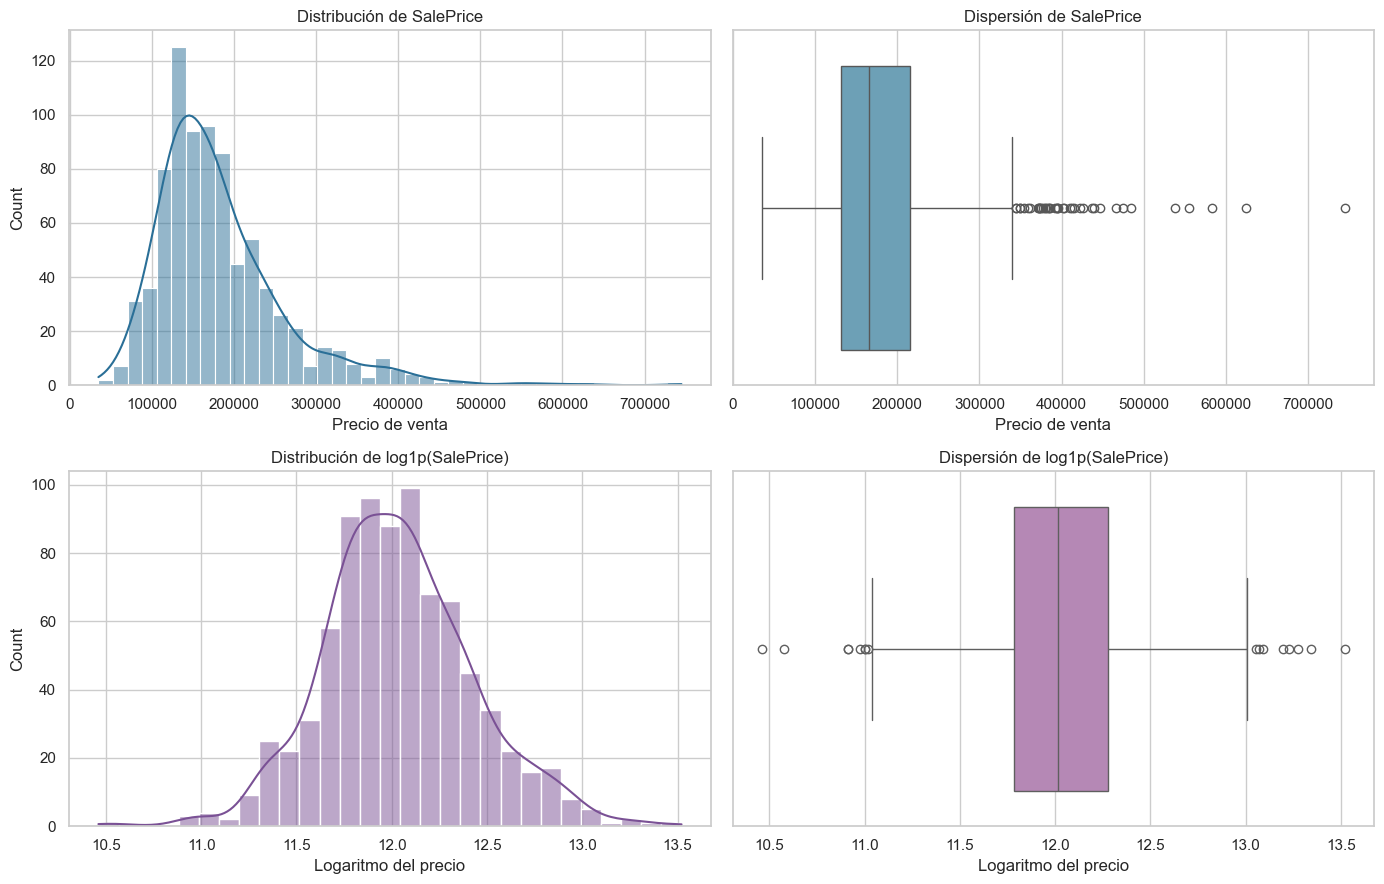

Asimetría original: 1.891
Asimetría con log1p: 0.195


In [43]:
precio_entrenamiento = df_entrenamiento[VARIABLE_OBJETIVO]
precio_log_entrenamiento = np.log1p(precio_entrenamiento)

fig, ejes = plt.subplots(2, 2, figsize=(14, 9))

sns.histplot(precio_entrenamiento, kde=True, ax=ejes[0, 0], color="#2A6F97")
ejes[0, 0].set_title("Distribución de SalePrice")
ejes[0, 0].set_xlabel("Precio de venta")

sns.boxplot(x=precio_entrenamiento, ax=ejes[0, 1], color="#61A5C2")
ejes[0, 1].set_title("Dispersión de SalePrice")
ejes[0, 1].set_xlabel("Precio de venta")

sns.histplot(precio_log_entrenamiento, kde=True, ax=ejes[1, 0], color="#7A5195")
ejes[1, 0].set_title("Distribución de log1p(SalePrice)")
ejes[1, 0].set_xlabel("Logaritmo del precio")

sns.boxplot(x=precio_log_entrenamiento, ax=ejes[1, 1], color="#BC80BD")
ejes[1, 1].set_title("Dispersión de log1p(SalePrice)")
ejes[1, 1].set_xlabel("Logaritmo del precio")

plt.tight_layout()
plt.show()

print(f"Asimetría original: {precio_entrenamiento.skew():.3f}")
print(f"Asimetría con log1p: {precio_log_entrenamiento.skew():.3f}")

In [44]:
columnas_categoricas_eda = df_entrenamiento.select_dtypes(include="object").columns.tolist()
columnas_categoricas_eda.append("MSSubClass")

columnas_numericas_eda = [
    columna
    for columna in df_entrenamiento.select_dtypes(include=np.number).columns
    if columna not in [VARIABLE_OBJETIVO, "MSSubClass"]
]

resumen_distribuciones_numericas = pd.DataFrame(
    {
        "Variable": columnas_numericas_eda,
        "Valores únicos": [df_entrenamiento[c].nunique(dropna=False) for c in columnas_numericas_eda],
        "Faltantes (%)": [df_entrenamiento[c].isna().mean() * 100 for c in columnas_numericas_eda],
        "Ceros (%)": [df_entrenamiento[c].eq(0).mean() * 100 for c in columnas_numericas_eda],
        "Asimetría": [df_entrenamiento[c].skew() for c in columnas_numericas_eda],
    }
).sort_values("Asimetría", ascending=False)

filas_categoricas = []
for columna in columnas_categoricas_eda:
    frecuencias = df_entrenamiento[columna].fillna("Ausente").astype(str).value_counts()
    filas_categoricas.append(
        {
            "Variable": columna,
            "Categorías": len(frecuencias),
            "Categoría dominante": frecuencias.index[0],
            "Frecuencia dominante (%)": frecuencias.iloc[0] / len(df_entrenamiento) * 100,
        }
    )

resumen_distribuciones_categoricas = pd.DataFrame(filas_categoricas).sort_values(
    "Frecuencia dominante (%)",
    ascending=False,
)

display(resumen_distribuciones_numericas.round(2))
display(resumen_distribuciones_categoricas.round(2))

,Variable,Valores únicos,Faltantes (%),Ceros (%),Asimetría
33,MiscVal,14,0.00,96.94,19.30
32,PoolArea,6,0.00,99.39,12.91
2,LotArea,646,0.00,0.00,11.88
30,3SsnPorch,12,0.00,98.65,11.57
14,LowQualFinSF,16,0.00,97.92,8.71
21,KitchenAbvGr,3,0.00,0.00,4.43
17,BsmtHalfBath,2,0.00,94.85,4.07
31,ScreenPorch,50,0.00,91.54,3.93
9,BsmtFinSF2,93,0.00,87.62,3.88
29,EnclosedPorch,77,0.00,86.52,3.40


,Variable,Categorías,Categoría dominante,Frecuencia dominante (%)
5,Utilities,1,AllPub,100.00
1,Street,2,Pave,99.63
38,PoolQC,4,Ausente,99.39
10,Condition2,8,Norm,98.90
14,RoofMatl,6,CompShg,98.41
26,Heating,6,GasA,97.06
40,MiscFeature,5,Ausente,96.69
7,LandSlope,3,Gtl,94.98
2,Alley,3,Ausente,93.14
31,Functional,7,Typ,92.40


#### **Relación de cada variable con SalePrice**

Para las variables numéricas se calculan Pearson, Spearman e información mutua, ya que una sola medida podría omitir relaciones monotónicas o no lineales. En el caso de las categóricas se utiliza eta cuadrado para medir qué proporción de la variación del precio se relaciona con las diferencias entre categorías, y nuevamente se agrega información mutua como complemento. Estas métricas permiten priorizar variables, pero no se interpretan como causalidad ni como una regla automática para descartar predictores.

In [45]:
def calcular_eta_cuadrado(categorias, objetivo):
    categorias_limpias = categorias.fillna("Ausente").astype(str)
    promedio_global = objetivo.mean()
    resumen_grupos = pd.DataFrame(
        {"Categoria": categorias_limpias, "Objetivo": objetivo}
    ).groupby("Categoria")["Objetivo"].agg(["count", "mean"])

    suma_cuadrados_entre = (
        resumen_grupos["count"]
        * (resumen_grupos["mean"] - promedio_global) ** 2
    ).sum()
    suma_cuadrados_total = ((objetivo - promedio_global) ** 2).sum()
    return suma_cuadrados_entre / suma_cuadrados_total if suma_cuadrados_total else 0.0


def calcular_asociaciones(datos, objetivo):
    y = datos[objetivo]
    categoricas = datos.select_dtypes(include="object").columns.tolist()
    categoricas.append("MSSubClass")
    numericas = [
        columna
        for columna in datos.select_dtypes(include=np.number).columns
        if columna not in [objetivo, "MSSubClass"]
    ]
    resultados = []

    for columna in numericas:
        serie = datos[columna].fillna(datos[columna].median())
        tiene_variacion = serie.nunique() > 1
        pearson = serie.corr(y, method="pearson") if tiene_variacion else 0.0
        spearman = serie.corr(y, method="spearman") if tiene_variacion else 0.0
        informacion_mutua = (
            mutual_info_regression(
                serie.to_numpy().reshape(-1, 1),
                y,
                random_state=SEMILLA,
            )[0]
            if tiene_variacion
            else 0.0
        )
        resultados.append(
            {
                "Variable": columna,
                "Tipo": "Numérica",
                "Pearson": pearson,
                "Spearman": spearman,
                "Eta cuadrado": np.nan,
                "Información mutua": informacion_mutua,
                "Fuerza exploratoria": max(abs(pearson), abs(spearman)),
            }
        )

    for columna in categoricas:
        serie = datos[columna].fillna("Ausente").astype(str)
        eta_cuadrado = calcular_eta_cuadrado(serie, y)
        codigos, _ = pd.factorize(serie)
        informacion_mutua = (
            mutual_info_regression(
                codigos.reshape(-1, 1),
                y,
                discrete_features=True,
                random_state=SEMILLA,
            )[0]
            if serie.nunique() > 1
            else 0.0
        )
        resultados.append(
            {
                "Variable": columna,
                "Tipo": "Categórica",
                "Pearson": np.nan,
                "Spearman": np.nan,
                "Eta cuadrado": eta_cuadrado,
                "Información mutua": informacion_mutua,
                "Fuerza exploratoria": np.sqrt(eta_cuadrado),
            }
        )

    resumen = pd.DataFrame(resultados)
    resumen["Ranking dentro del tipo"] = resumen.groupby("Tipo")[
        "Fuerza exploratoria"
    ].rank(method="min", ascending=False)
    resumen["Uso inicial"] = np.where(
        resumen["Variable"].eq("Id"),
        "Excluir: identificador",
        "Conservar para validación",
    )
    return resumen.sort_values("Fuerza exploratoria", ascending=False).reset_index(drop=True)


resumen_asociaciones = calcular_asociaciones(df_entrenamiento, VARIABLE_OBJETIVO)
display(resumen_asociaciones.round(4))

,Variable,Tipo,Pearson,Spearman,Eta cuadrado,Información mutua,Fuerza exploratoria,Ranking dentro del tipo,Uso inicial
0,OverallQual,Numérica,0.7832,0.7989,NaN,0.5253,0.7989,1.0,Conservar para validación
1,Neighborhood,Categórica,NaN,NaN,0.5776,0.5611,0.7600,1.0,Conservar para validación
2,GrLivArea,Numérica,0.6878,0.7080,NaN,0.4435,0.7080,2.0,Conservar para validación
3,KitchenQual,Categórica,NaN,NaN,0.4725,0.3228,0.6874,2.0,Conservar para validación
4,GarageCars,Numérica,0.6347,0.6834,NaN,0.3454,0.6834,3.0,Conservar para validación
...,...,...,...,...,...,...,...,...,...
75,BsmtFinSF2,Numérica,-0.0057,-0.0239,NaN,0.0000,0.0239,34.0,Conservar para validación
76,Id,Numérica,-0.0194,-0.0148,NaN,0.0000,0.0194,35.0,Excluir: identificador
77,YrSold,Numérica,-0.0062,-0.0082,NaN,0.0484,0.0082,36.0,Conservar para validación
78,Street,Categórica,NaN,NaN,0.0000,0.0000,0.0035,43.0,Conservar para validación


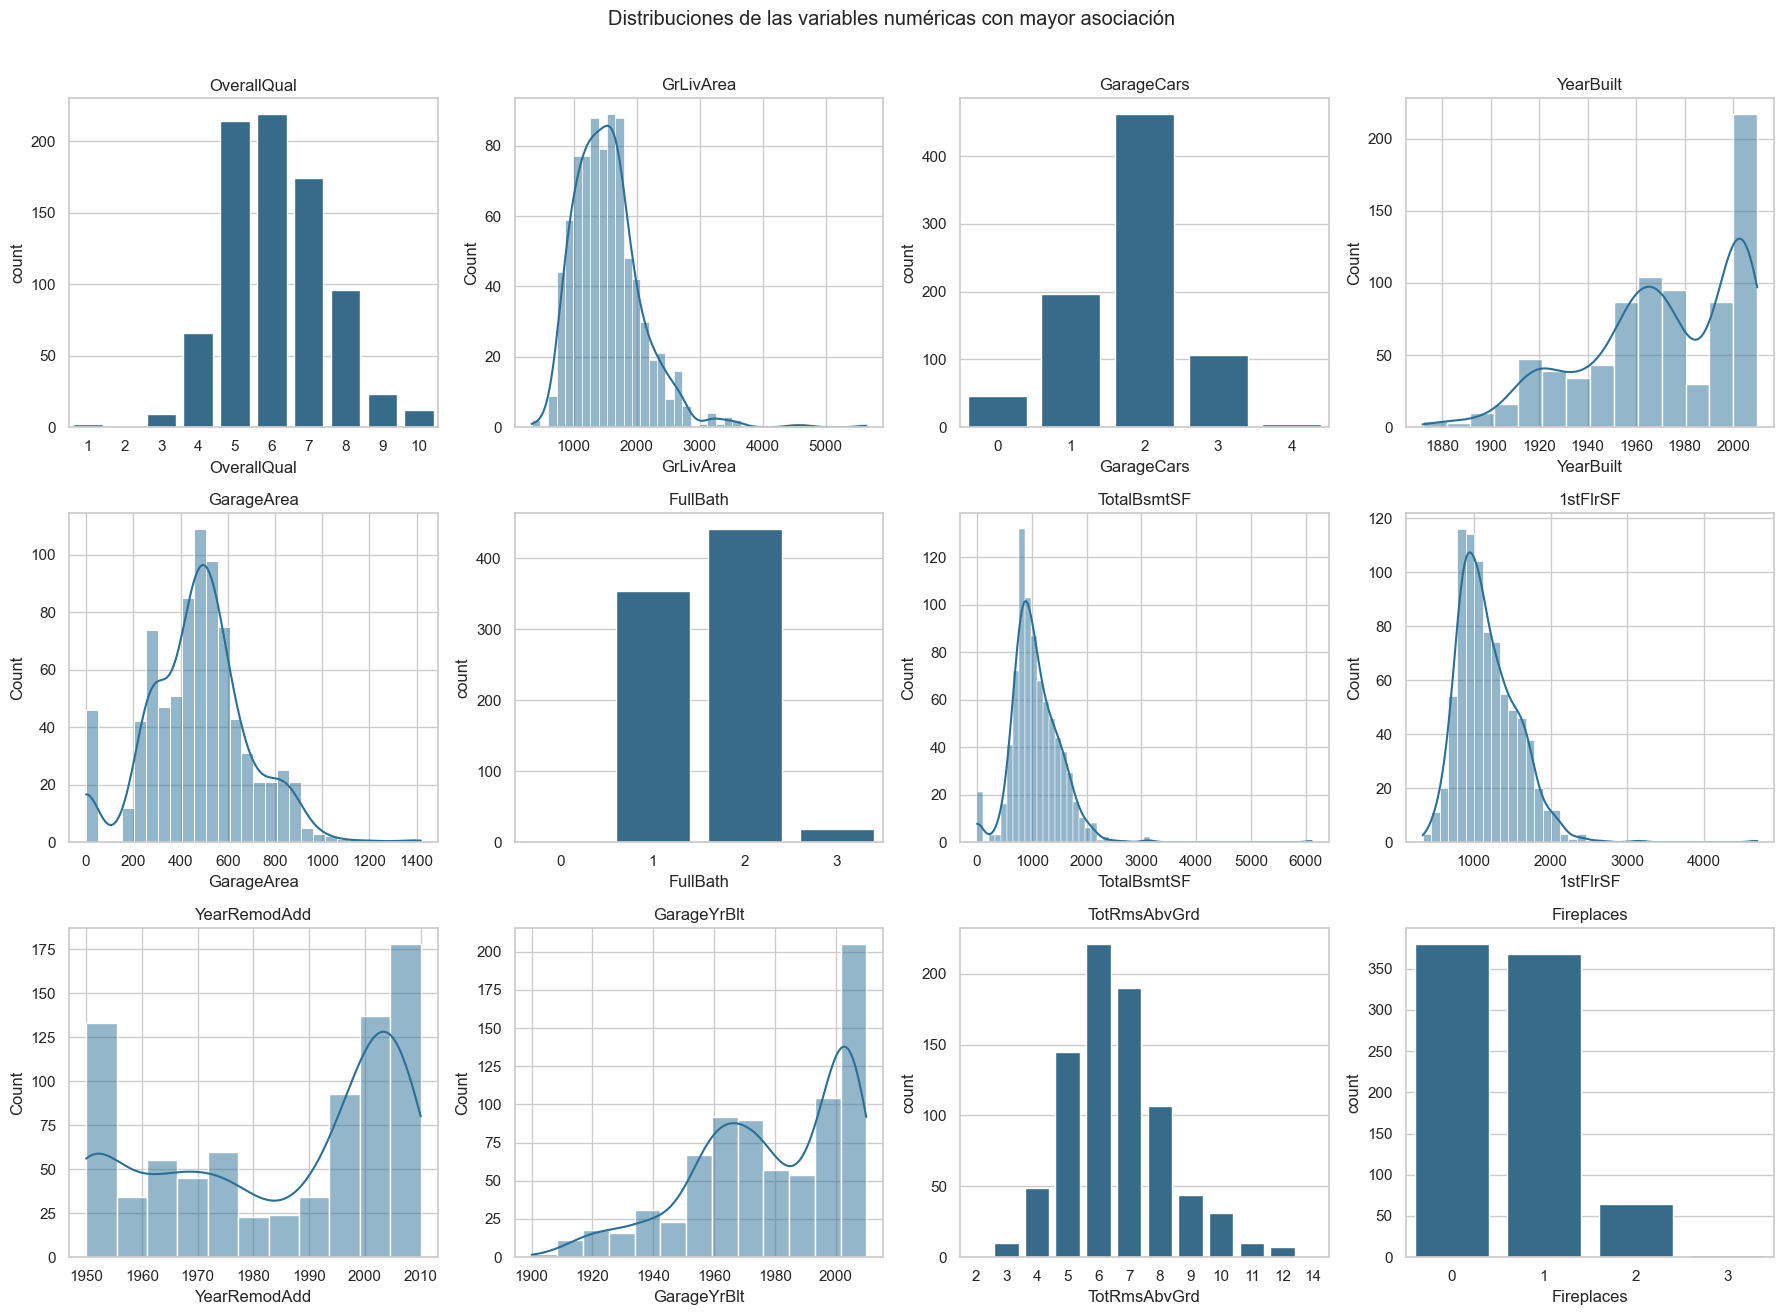

In [46]:
top_numericas = resumen_asociaciones.loc[
    resumen_asociaciones["Tipo"].eq("Numérica")
    & resumen_asociaciones["Variable"].ne("Id"),
    "Variable",
].head(12).tolist()

fig, ejes = plt.subplots(3, 4, figsize=(18, 13))
for eje, variable in zip(ejes.flat, top_numericas):
    serie = df_entrenamiento[variable].dropna()
    if serie.nunique() <= 15:
        sns.countplot(x=serie, ax=eje, color="#2A6F97")
    else:
        sns.histplot(serie, kde=True, ax=eje, color="#2A6F97")
    eje.set_title(variable)

plt.suptitle("Distribuciones de las variables numéricas con mayor asociación", y=1.01)
plt.tight_layout()
plt.show()

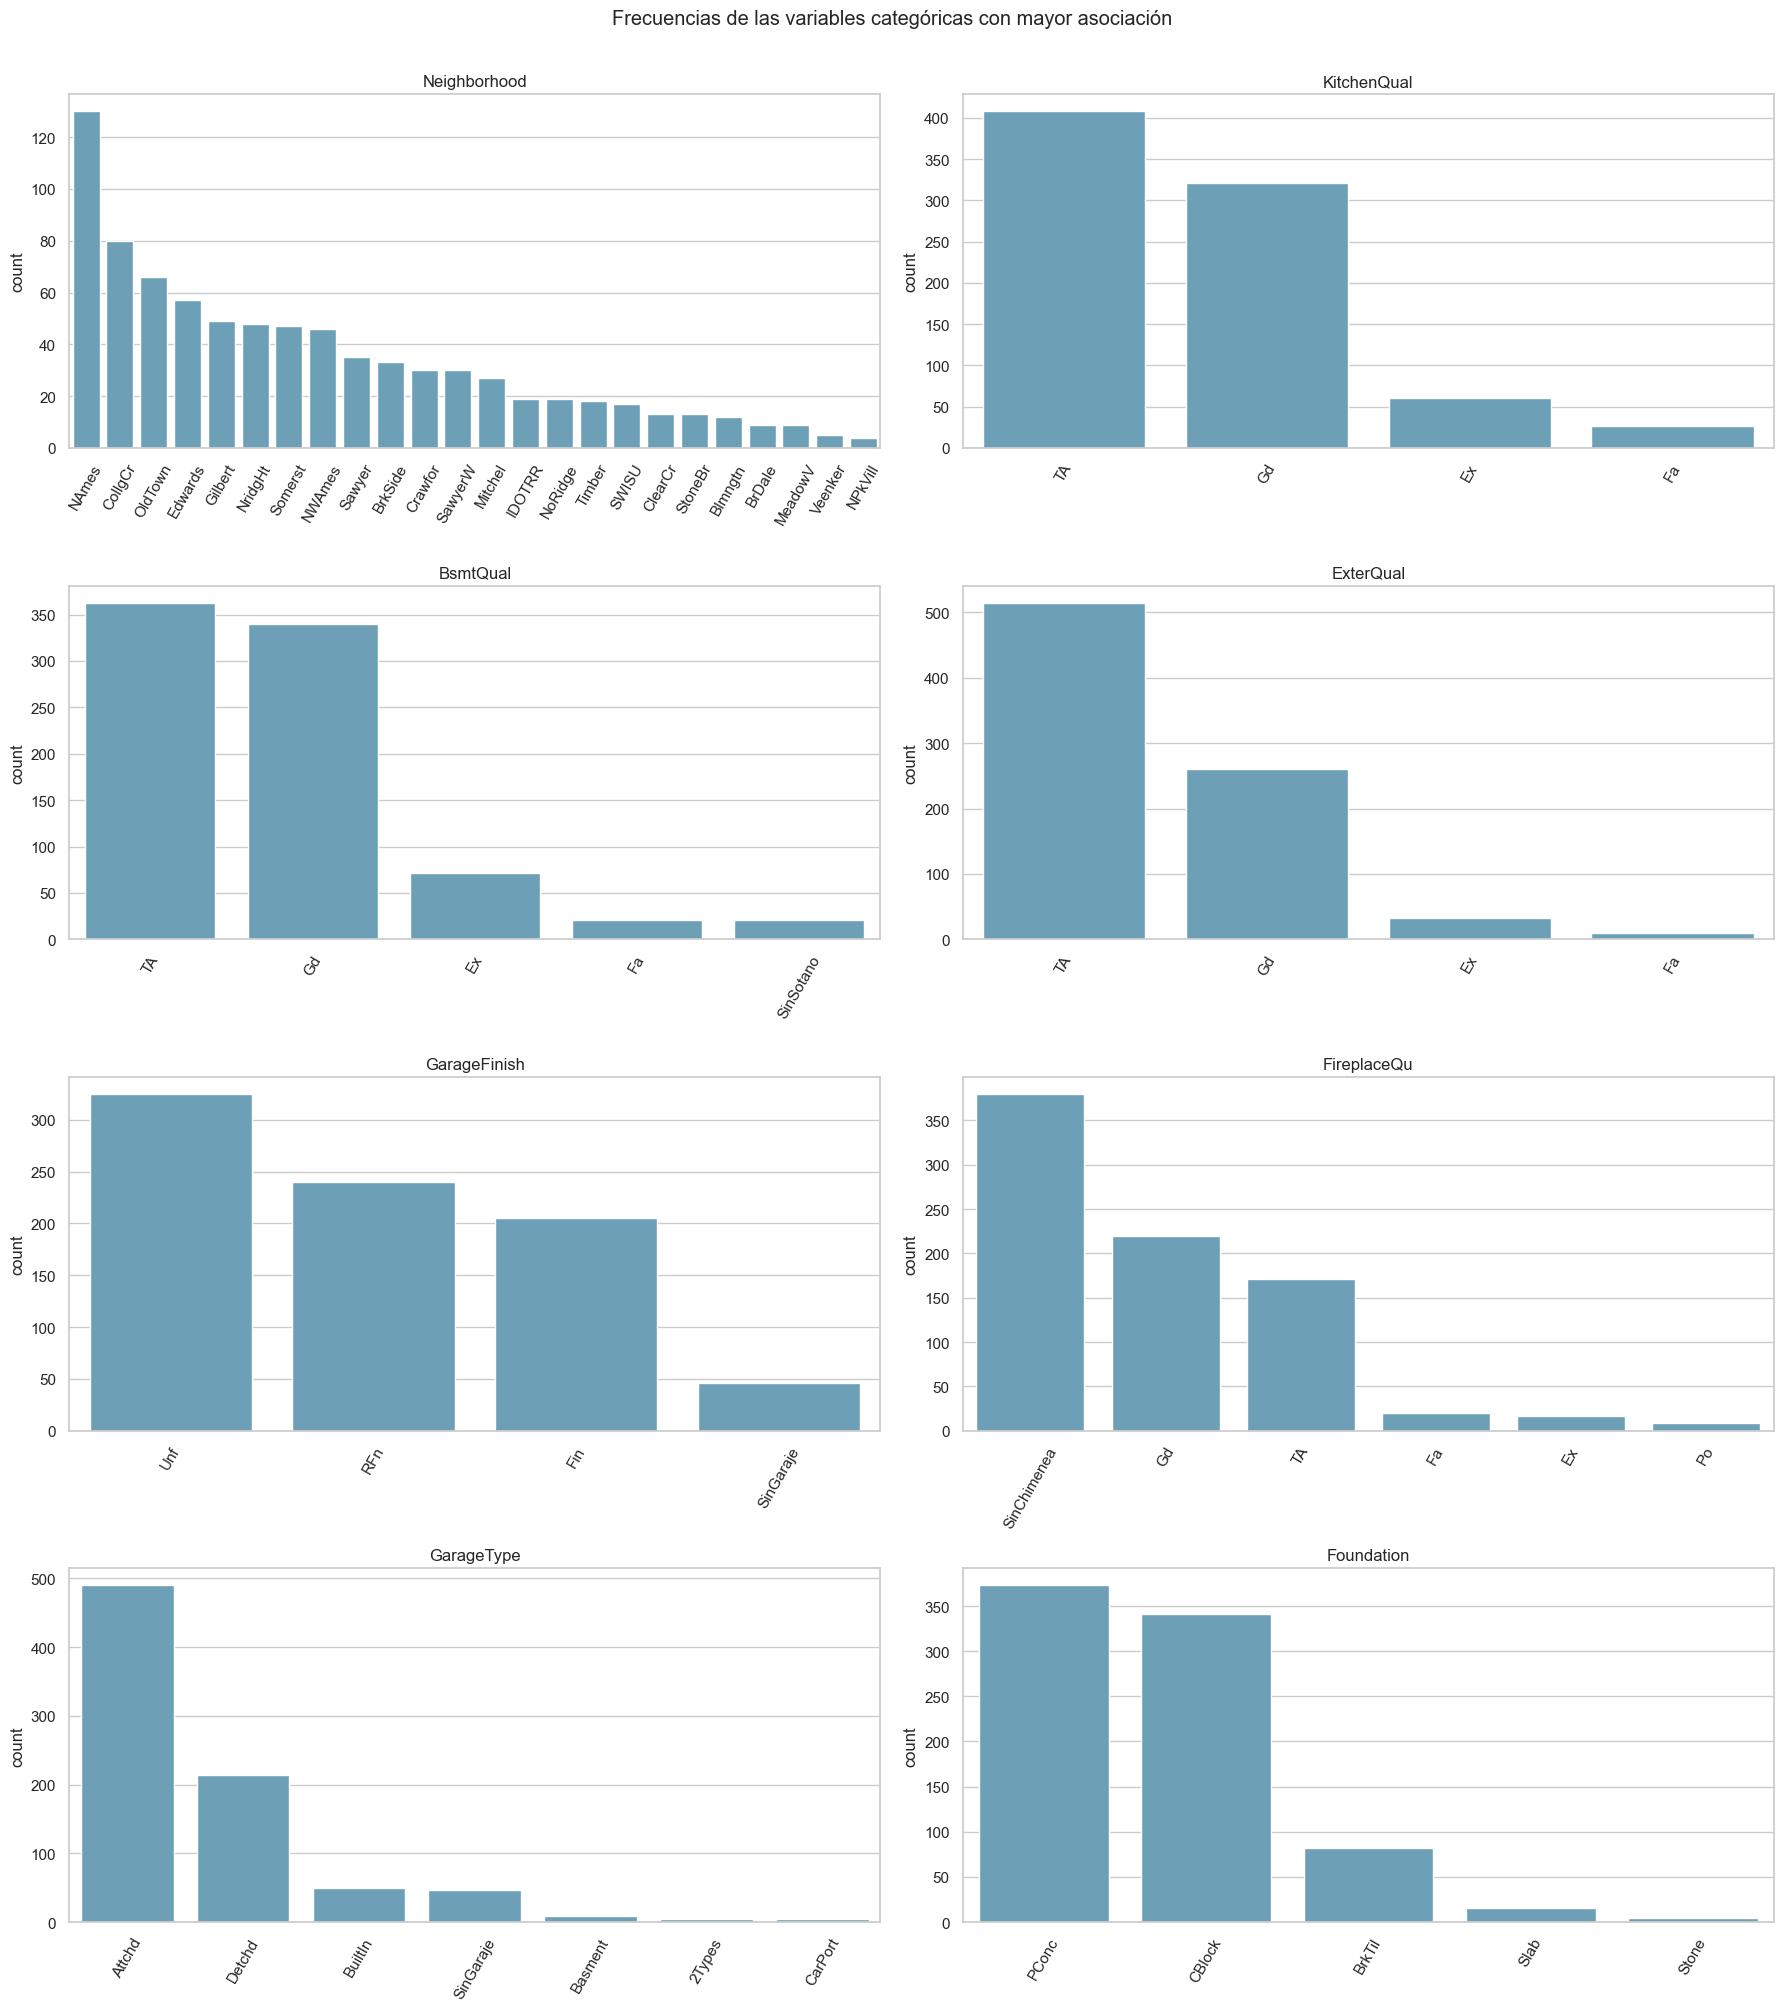

In [47]:
etiquetas_ausencia_eda = {
    "Alley": "SinCallejon",
    "BsmtQual": "SinSotano",
    "BsmtCond": "SinSotano",
    "BsmtExposure": "SinSotano",
    "BsmtFinType1": "SinSotano",
    "BsmtFinType2": "SinSotano",
    "FireplaceQu": "SinChimenea",
    "GarageType": "SinGaraje",
    "GarageFinish": "SinGaraje",
    "GarageQual": "SinGaraje",
    "GarageCond": "SinGaraje",
    "PoolQC": "SinPiscina",
    "Fence": "SinCerca",
    "MiscFeature": "SinCaracteristica",
    "MasVnrType": "Desconocido",
}


def preparar_categoria_eda(datos, variable):
    etiqueta = etiquetas_ausencia_eda.get(variable, "Desconocido")
    return datos[variable].fillna(etiqueta).astype(str)


top_categoricas = resumen_asociaciones.loc[
    resumen_asociaciones["Tipo"].eq("Categórica"),
    "Variable",
].head(8).tolist()

fig, ejes = plt.subplots(4, 2, figsize=(18, 20))
for eje, variable in zip(ejes.flat, top_categoricas):
    serie = preparar_categoria_eda(df_entrenamiento, variable)
    orden = serie.value_counts().index
    sns.countplot(x=serie, order=orden, ax=eje, color="#61A5C2")
    eje.set_title(variable)
    eje.set_xlabel("")
    eje.tick_params(axis="x", rotation=60)

plt.suptitle("Frecuencias de las variables categóricas con mayor asociación", y=1.005)
plt.tight_layout()
plt.show()

#### **Correlaciones entre predictores**

La matriz se construye con Spearman porque varias variables presentan asimetría y valores extremos. Para no perder información, además de mostrar las variables numéricas más relacionadas con SalePrice se revisan todos los pares numéricos y se listan aquellos cuya correlación absoluta es al menos 0.75. Este resultado se utilizará para reconocer redundancia y proponer ablaciones, no para eliminar automáticamente una de las variables.

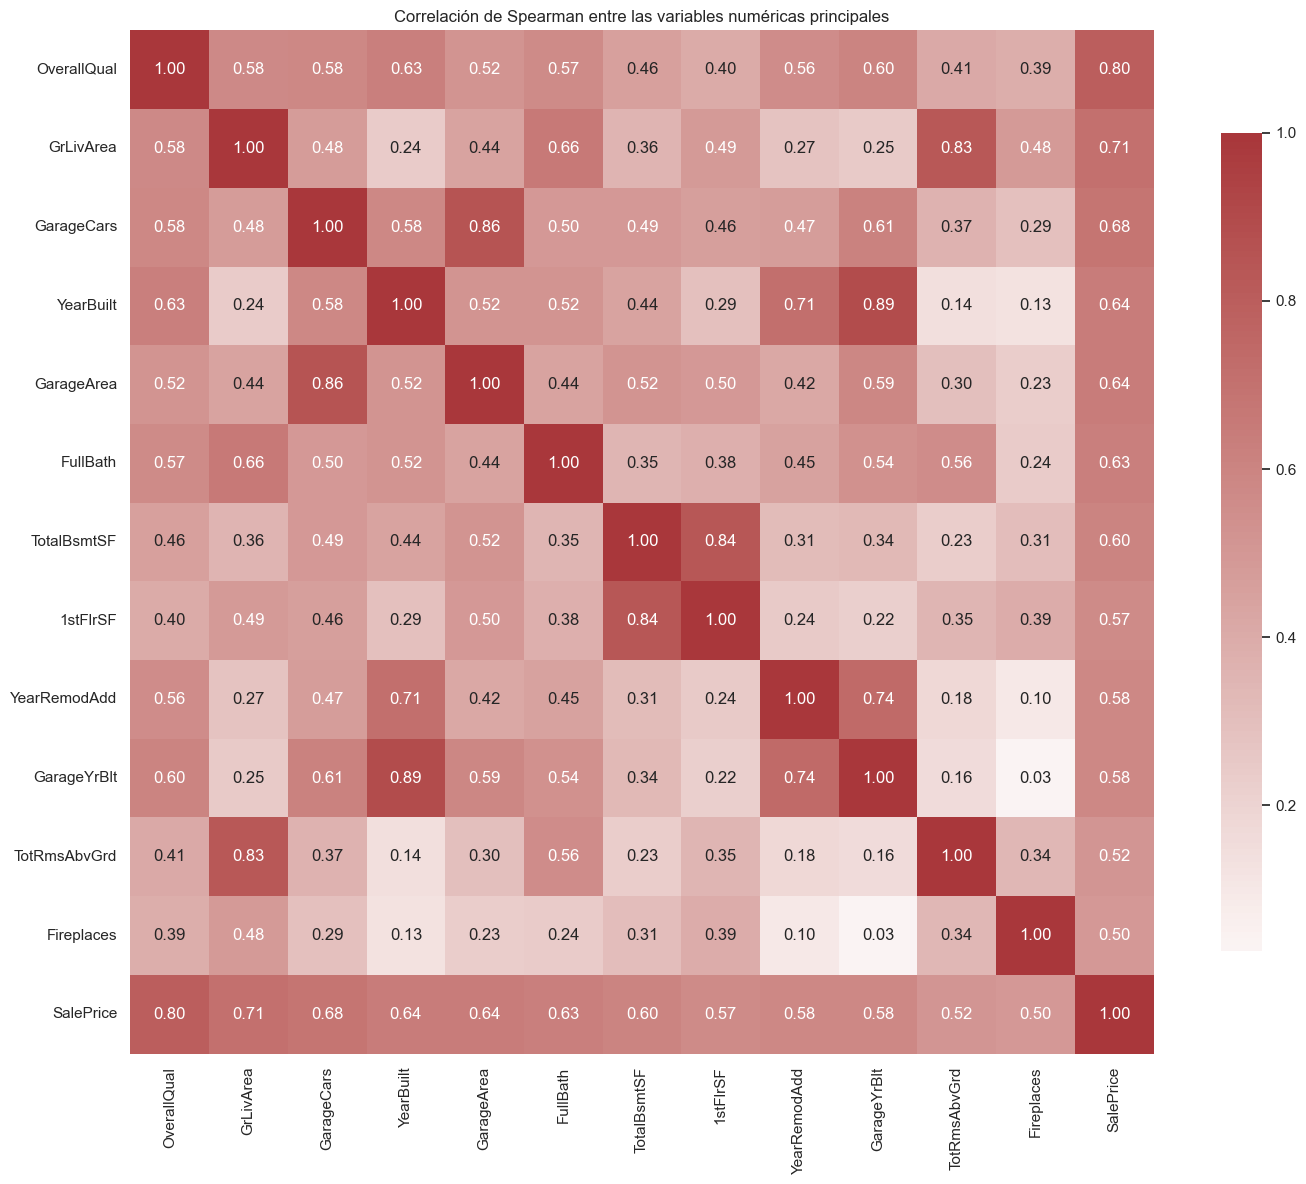

,Variable A,Variable B,Spearman
0,YearBuilt,GarageYrBlt,0.892
1,GarageCars,GarageArea,0.857
2,TotalBsmtSF,1stFlrSF,0.838
3,GrLivArea,TotRmsAbvGrd,0.832


In [48]:
variables_matriz = top_numericas[:18] + [VARIABLE_OBJETIVO]
matriz_spearman = df_entrenamiento[variables_matriz].corr(method="spearman")

plt.figure(figsize=(15, 12))
sns.heatmap(
    matriz_spearman,
    cmap="vlag",
    center=0,
    annot=True,
    fmt=".2f",
    square=True,
    cbar_kws={"shrink": 0.8},
)
plt.title("Correlación de Spearman entre las variables numéricas principales")
plt.tight_layout()
plt.show()

numericas_sin_identificador = [
    variable for variable in columnas_numericas_eda if variable != "Id"
]
correlaciones_predictores = df_entrenamiento[numericas_sin_identificador].corr(
    method="spearman"
)
pares_correlacion_alta = []

for posicion, variable_a in enumerate(correlaciones_predictores.columns):
    for variable_b in correlaciones_predictores.columns[posicion + 1:]:
        correlacion = correlaciones_predictores.loc[variable_a, variable_b]
        if abs(correlacion) >= 0.75:
            pares_correlacion_alta.append(
                {
                    "Variable A": variable_a,
                    "Variable B": variable_b,
                    "Spearman": correlacion,
                }
            )

pares_correlacion_alta = pd.DataFrame(pares_correlacion_alta)
if not pares_correlacion_alta.empty:
    pares_correlacion_alta = pares_correlacion_alta.reindex(
        pares_correlacion_alta["Spearman"].abs().sort_values(ascending=False).index
    ).reset_index(drop=True)

display(pares_correlacion_alta.round(3))

#### **Relaciones principales con la variable objetivo**

Las siguientes gráficas se concentran en las asociaciones más fuertes para poder discutirlas con claridad. No obstante, la tabla anterior conserva el resultado de cada predictor y la función incluida al final permite generar la relación de cualquier variable específica cuando sea necesario.

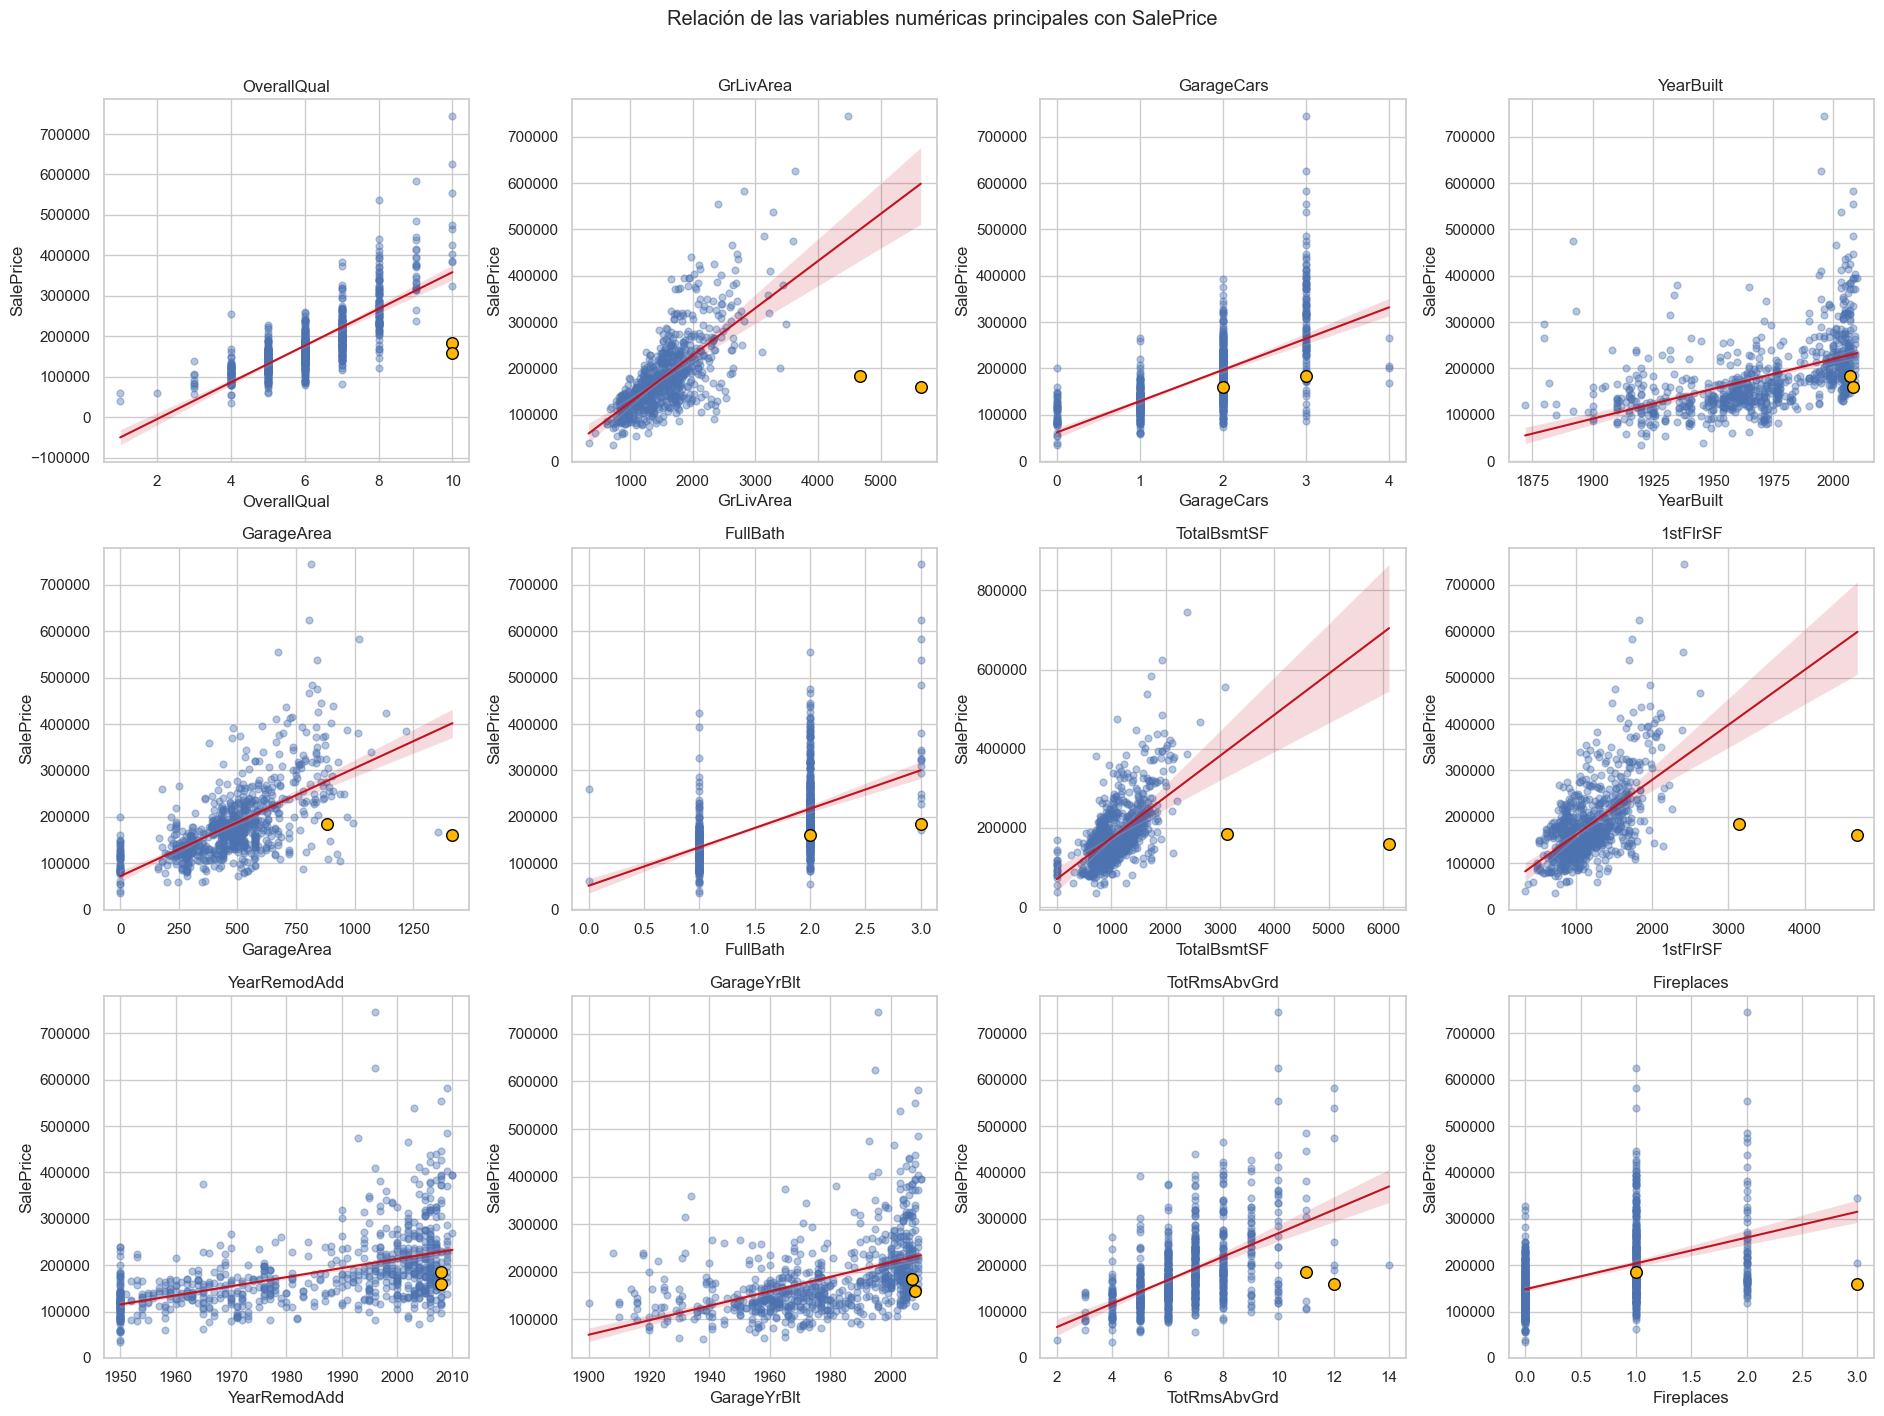

In [49]:
fig, ejes = plt.subplots(3, 4, figsize=(19, 14))
casos_contextuales = df_entrenamiento[df_entrenamiento["Id"].isin([524, 1299])]

for eje, variable in zip(ejes.flat, top_numericas):
    sns.regplot(
        data=df_entrenamiento,
        x=variable,
        y=VARIABLE_OBJETIVO,
        scatter_kws={"alpha": 0.4, "s": 24},
        line_kws={"color": "#C1121F", "linewidth": 1.5},
        ax=eje,
    )
    eje.scatter(
        casos_contextuales[variable],
        casos_contextuales[VARIABLE_OBJETIVO],
        color="#FFB703",
        edgecolor="black",
        s=70,
        zorder=5,
    )
    eje.set_title(variable)

plt.suptitle("Relación de las variables numéricas principales con SalePrice", y=1.01)
plt.tight_layout()
plt.show()

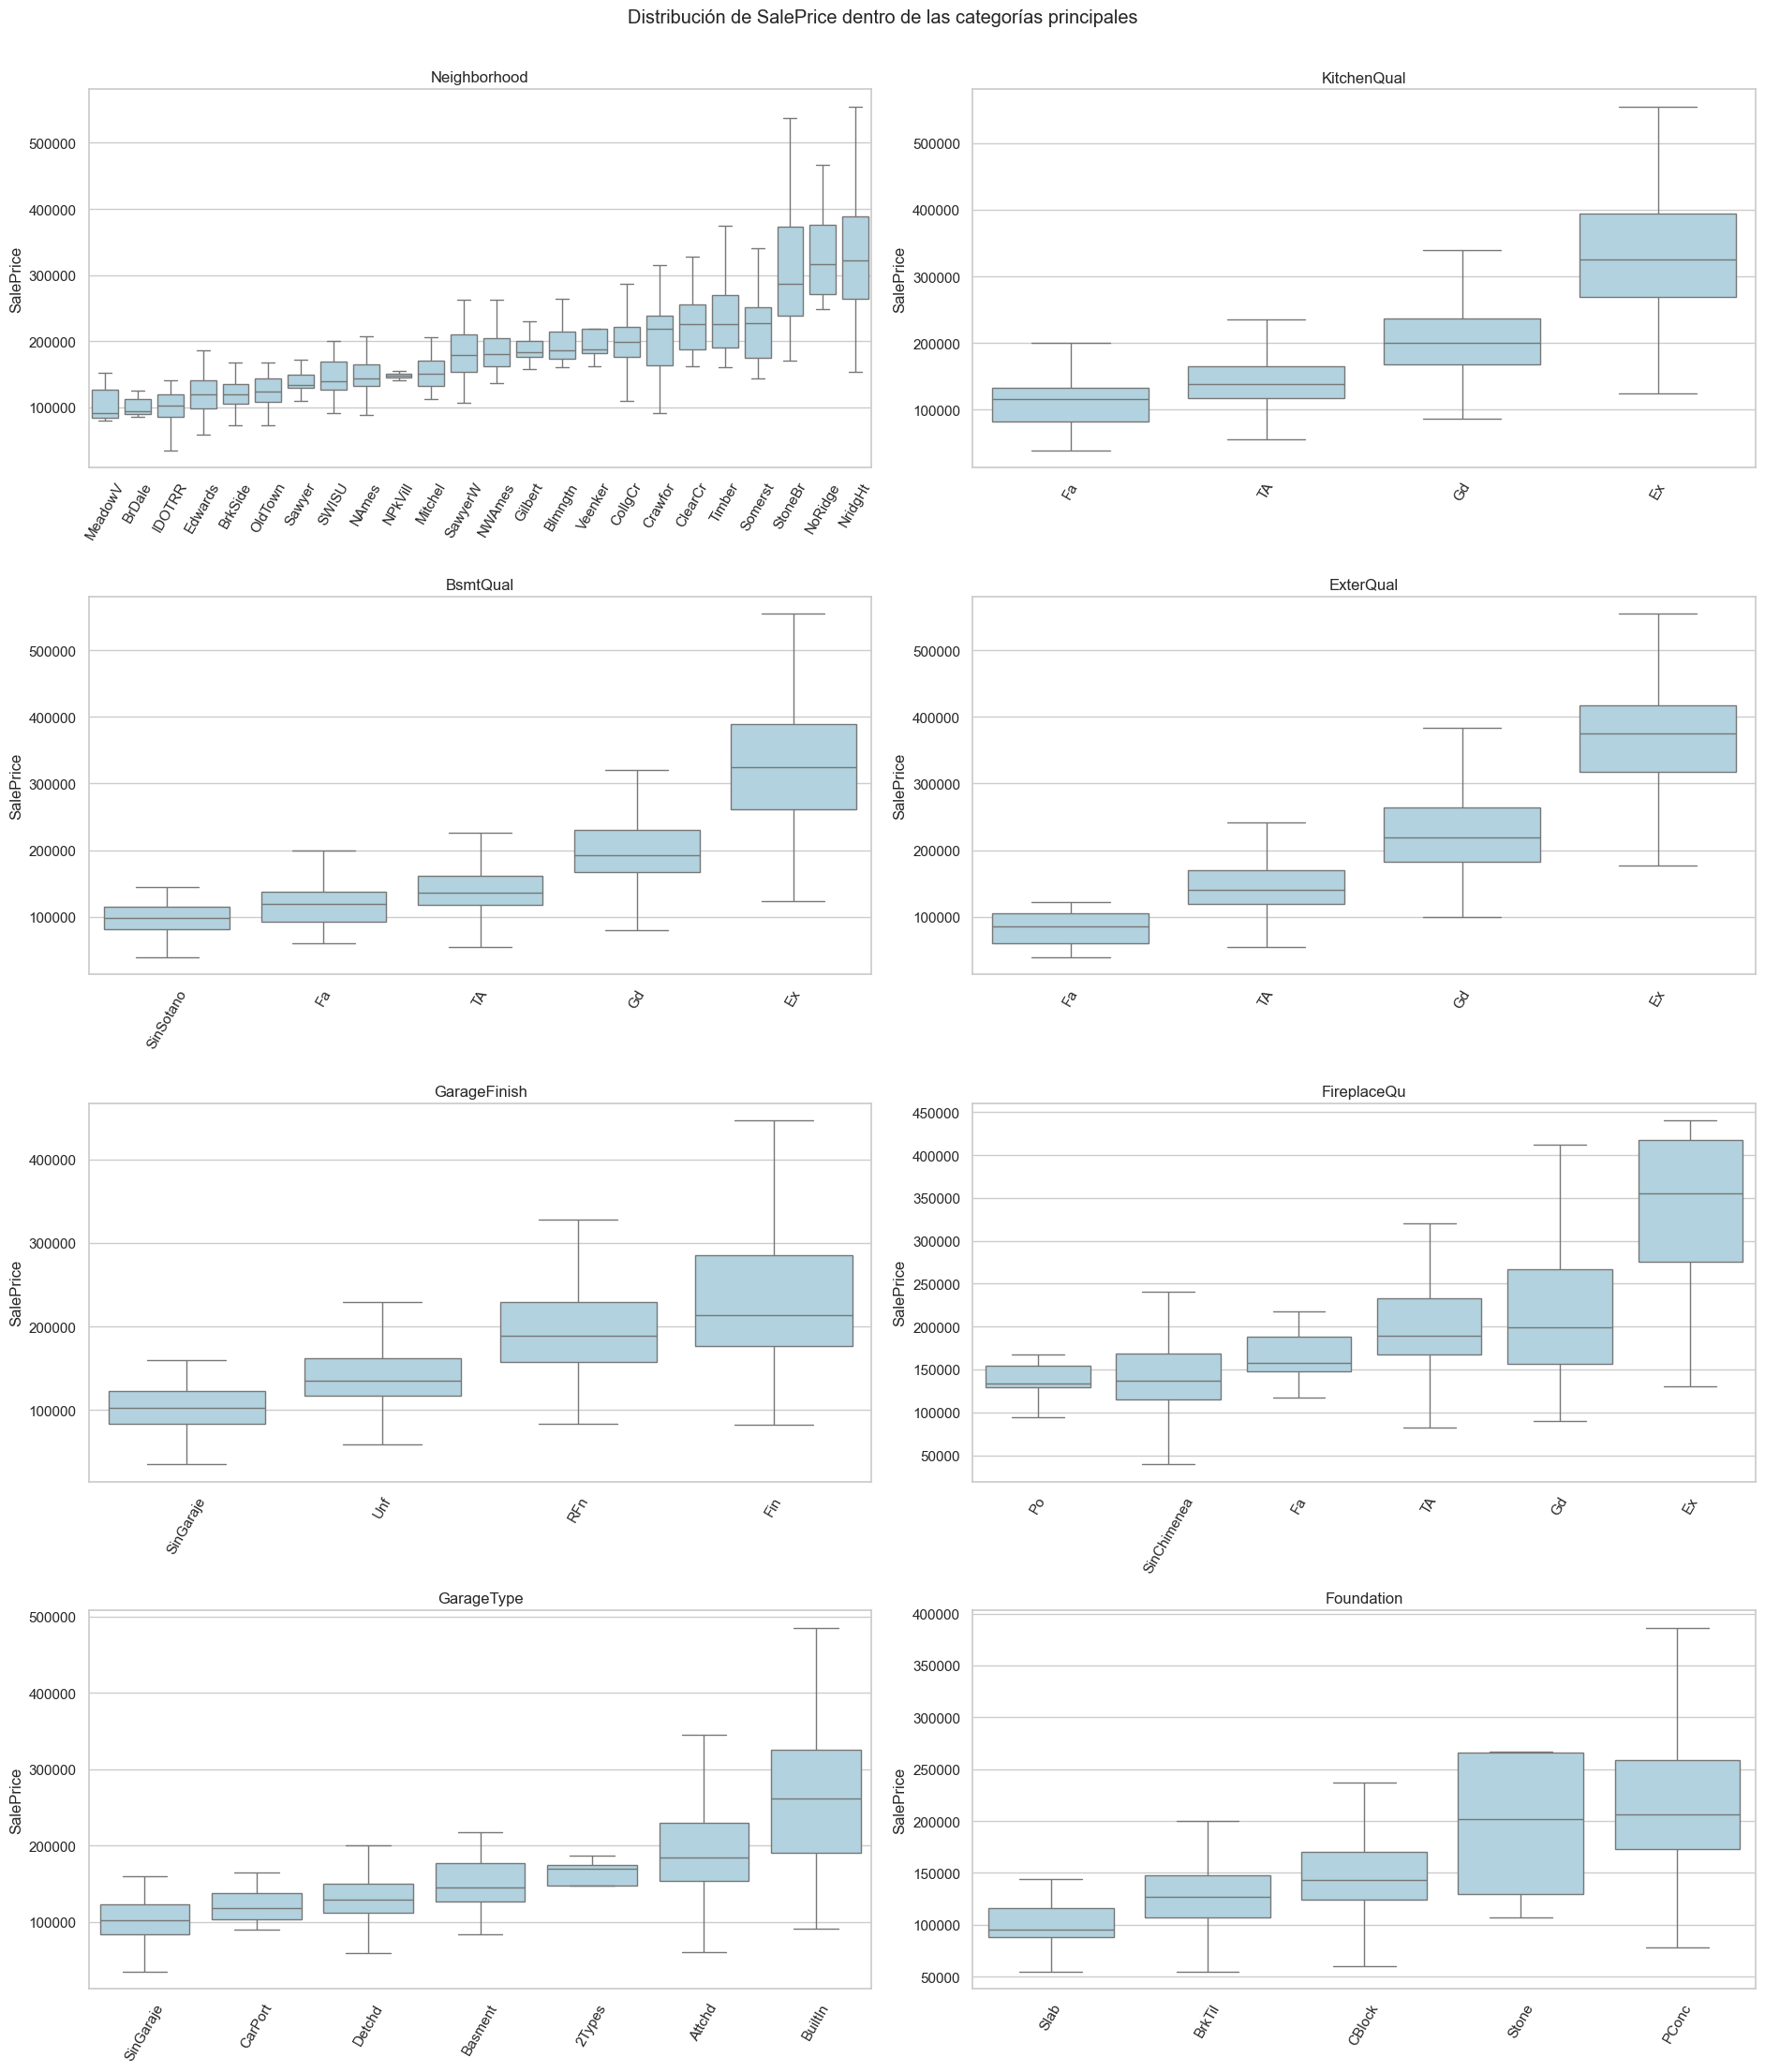

In [50]:
fig, ejes = plt.subplots(4, 2, figsize=(19, 22))

for eje, variable in zip(ejes.flat, top_categoricas):
    categorias = preparar_categoria_eda(df_entrenamiento, variable)
    datos_grafica = pd.DataFrame(
        {variable: categorias, VARIABLE_OBJETIVO: df_entrenamiento[VARIABLE_OBJETIVO]}
    )
    orden = datos_grafica.groupby(variable)[VARIABLE_OBJETIVO].median().sort_values().index
    sns.boxplot(
        data=datos_grafica,
        x=variable,
        y=VARIABLE_OBJETIVO,
        order=orden,
        ax=eje,
        color="#A9D6E5",
        showfliers=False,
    )
    eje.set_title(variable)
    eje.set_xlabel("")
    eje.tick_params(axis="x", rotation=60)

plt.suptitle("Distribución de SalePrice dentro de las categorías principales", y=1.005)
plt.tight_layout()
plt.show()


def visualizar_relacion_con_objetivo(variable, datos=df_entrenamiento):
    if variable not in datos.columns or variable == VARIABLE_OBJETIVO:
        raise ValueError("Se debe indicar una variable predictora existente.")

    plt.figure(figsize=(12, 6))
    if datos[variable].dtype == "object" or variable == "MSSubClass":
        categorias = preparar_categoria_eda(datos, variable)
        datos_grafica = pd.DataFrame(
            {variable: categorias, VARIABLE_OBJETIVO: datos[VARIABLE_OBJETIVO]}
        )
        orden = datos_grafica.groupby(variable)[VARIABLE_OBJETIVO].median().sort_values().index
        sns.boxplot(
            data=datos_grafica,
            x=variable,
            y=VARIABLE_OBJETIVO,
            order=orden,
            color="#A9D6E5",
        )
        plt.xticks(rotation=60)
    else:
        sns.regplot(
            data=datos,
            x=variable,
            y=VARIABLE_OBJETIVO,
            scatter_kws={"alpha": 0.45},
            line_kws={"color": "#C1121F"},
        )

    plt.title(f"Relación entre {variable} y {VARIABLE_OBJETIVO}")
    plt.tight_layout()
    plt.show()

#### **Hallazgos para la selección posterior de variables**

Primero, OverallQual presenta la relación numérica más fuerte con el precio, seguido por GrLivArea, GarageCars, GarageArea, YearBuilt y TotalBsmtSF. Entre las categóricas destacan Neighborhood, KitchenQual, BsmtQual y ExterQual, lo cual parece coherente porque representan la ubicación y la calidad de distintas partes de la vivienda. Asimismo, la información mutua conserva varias de estas variables en las primeras posiciones, por lo que su aporte no parece depender únicamente de una relación lineal.

Por otro lado, GarageCars con GarageArea, TotalBsmtSF con 1stFlrSF, GrLivArea con TotRmsAbvGrd, y YearBuilt con GarageYrBlt presentan asociaciones elevadas entre sí. Considero que todavía no conviene eliminar ninguna de ellas, ya que una red puede aprovechar diferencias que no aparecen en una correlación bivariada. En cambio, estos pares se utilizarán para construir grupos de ablación y comprobar si conservar ambas variables mejora realmente la validación.

Finalmente, SalePrice reduce de forma considerable su asimetría después de aplicar log1p, mientras que variables de área y características poco frecuentes también presentan colas derechas pronunciadas. Bajo esta idea, se preparará una ruta con transformaciones logarítmicas y otra que permita comparar el efecto de los valores extremos, pero la selección final se dejará para el protocolo experimental.

### **Decisiones de preprocesamiento derivadas del EDA**

El preprocesamiento se construye como un pipeline para garantizar que las imputaciones, transformaciones y codificaciones se aprendan únicamente con la partición utilizada para entrenar. Esto también permitirá que, cuando se aplique validación cruzada, cada fold calcule sus propias medianas, modas y categorías, evitando que la información de las observaciones de validación influya en el ajuste.

Primero, Id se elimina porque solamente identifica una fila y no representa una característica de la vivienda, mientras que MSSubClass se convierte en categórica porque sus números funcionan como códigos. Luego, se mantienen las ausencias estructurales como categorías explícitas, LotFrontage se imputa mediante la mediana del vecindario y Electrical mediante la moda. En el caso de los años, GarageYrBlt se sustituye por la edad del garaje y un indicador de presencia, y también se agregan las edades de construcción y remodelación al momento de la venta.

Para las variables numéricas se prepara StandardScaler como ruta base, ya que resta la media y divide dentro de la desviación estándar, mientras que MinMaxScaler se conserva como una alternativa que lleva cada variable al rango entre cero y uno. También se mantiene RobustScaler para comprobar si el uso de la mediana y el rango intercuartílico reduce la influencia de los valores extremos. Asimismo, las variables no negativas con más de diez valores distintos y una asimetría absoluta mayor que uno pueden transformarse mediante log1p antes del escalado. Para las categóricas se deja una ruta completamente one-hot y otra mixta que conserva el orden conocido de las variables ordinales. Ninguna de estas alternativas se selecciona todavía; posteriormente deberán compararse con las mismas particiones y el mismo modelo base.

In [51]:
RELLENOS_ESTRUCTURALES = {
    "Alley": "SinCallejon",
    "BsmtQual": "SinSotano",
    "BsmtCond": "SinSotano",
    "BsmtExposure": "SinSotano",
    "BsmtFinType1": "SinSotano",
    "BsmtFinType2": "SinSotano",
    "FireplaceQu": "SinChimenea",
    "GarageType": "SinGaraje",
    "GarageFinish": "SinGaraje",
    "GarageQual": "SinGaraje",
    "GarageCond": "SinGaraje",
    "PoolQC": "SinPiscina",
    "Fence": "SinCerca",
    "MiscFeature": "SinCaracteristica",
}

CATEGORIAS_ORDENADAS = {
    "LotShape": ["IR3", "IR2", "IR1", "Reg"],
    "Utilities": ["ELO", "NoSeWa", "NoSewr", "AllPub"],
    "LandSlope": ["Sev", "Mod", "Gtl"],
    "ExterQual": ["Po", "Fa", "TA", "Gd", "Ex"],
    "ExterCond": ["Po", "Fa", "TA", "Gd", "Ex"],
    "BsmtQual": ["SinSotano", "Po", "Fa", "TA", "Gd", "Ex"],
    "BsmtCond": ["SinSotano", "Po", "Fa", "TA", "Gd", "Ex"],
    "BsmtExposure": ["SinSotano", "No", "Mn", "Av", "Gd"],
    "BsmtFinType1": ["SinSotano", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],
    "BsmtFinType2": ["SinSotano", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],
    "HeatingQC": ["Po", "Fa", "TA", "Gd", "Ex"],
    "KitchenQual": ["Po", "Fa", "TA", "Gd", "Ex"],
    "Functional": ["Sal", "Sev", "Maj2", "Maj1", "Mod", "Min2", "Min1", "Typ"],
    "FireplaceQu": ["SinChimenea", "Po", "Fa", "TA", "Gd", "Ex"],
    "GarageFinish": ["SinGaraje", "Unf", "RFn", "Fin"],
    "GarageQual": ["SinGaraje", "Po", "Fa", "TA", "Gd", "Ex"],
    "GarageCond": ["SinGaraje", "Po", "Fa", "TA", "Gd", "Ex"],
    "PavedDrive": ["N", "P", "Y"],
    "PoolQC": ["SinPiscina", "Fa", "TA", "Gd", "Ex"],
}


class TransformadorAmes(BaseEstimator, TransformerMixin):
    def __init__(self, eliminar_anios_originales=False):
        self.eliminar_anios_originales = eliminar_anios_originales

    def fit(self, X, y=None):
        datos = X.copy()
        self.mediana_frente_vecindario_ = datos.groupby("Neighborhood")[
            "LotFrontage"
        ].median()
        self.mediana_frente_global_ = datos["LotFrontage"].median()

        moda_electrical = datos["Electrical"].mode(dropna=True)
        self.moda_electrical_ = (
            moda_electrical.iloc[0] if not moda_electrical.empty else "Desconocido"
        )
        return self

    def transform(self, X):
        datos = X.copy()

        columnas_texto = datos.select_dtypes(include="object").columns
        for columna in columnas_texto:
            datos[columna] = datos[columna].astype("string").str.strip().str.strip("'")

        for columna, etiqueta in RELLENOS_ESTRUCTURALES.items():
            datos[columna] = datos[columna].fillna(etiqueta)

        datos["LotFrontageMissing"] = datos["LotFrontage"].isna().astype(int)
        medianas_fila = datos["Neighborhood"].map(self.mediana_frente_vecindario_)
        datos["LotFrontage"] = (
            datos["LotFrontage"]
            .fillna(medianas_fila)
            .fillna(self.mediana_frente_global_)
        )

        datos["MasVnrType"] = datos["MasVnrType"].fillna("Desconocido")
        datos["MasVnrArea"] = datos["MasVnrArea"].fillna(0)
        datos["Electrical"] = datos["Electrical"].fillna(self.moda_electrical_)

        datos["HasGarage"] = datos["GarageCars"].gt(0).astype(int)
        datos["GarageAge"] = datos["YrSold"] - datos["GarageYrBlt"]
        datos.loc[datos["HasGarage"].eq(0), "GarageAge"] = 0
        datos["GarageAge"] = datos["GarageAge"].fillna(0)

        datos["HouseAge"] = (datos["YrSold"] - datos["YearBuilt"]).clip(lower=0)
        edad_remodelacion = datos["YrSold"] - datos["YearRemodAdd"]
        datos["RemodAfterSale"] = edad_remodelacion.lt(0).astype(int)
        datos["RemodAge"] = edad_remodelacion.clip(lower=0)

        datos["MSSubClass"] = datos["MSSubClass"].astype("Int64").astype("string")

        columnas_restantes_texto = datos.select_dtypes(include=["object", "string"]).columns
        for columna in columnas_restantes_texto:
            datos[columna] = datos[columna].fillna("Desconocido")

        columnas_eliminar = ["Id", "GarageYrBlt"]
        if self.eliminar_anios_originales:
            columnas_eliminar.extend(["YearBuilt", "YearRemodAdd", "YrSold"])

        return datos.drop(columns=columnas_eliminar)


class TransformadorLogSesgo(BaseEstimator, TransformerMixin):
    def __init__(self, umbral=1.0, habilitado=True):
        self.umbral = umbral
        self.habilitado = habilitado

    def fit(self, X, y=None):
        datos = pd.DataFrame(X).copy()
        self.columnas_transformadas_ = []

        if self.habilitado:
            for columna in datos.columns:
                serie = pd.to_numeric(datos[columna], errors="coerce")
                valores_observados = serie.dropna()
                if (
                    not valores_observados.empty
                    and valores_observados.min() >= 0
                    and valores_observados.nunique() > 10
                    and abs(valores_observados.skew()) > self.umbral
                ):
                    self.columnas_transformadas_.append(columna)
        return self

    def transform(self, X):
        datos = pd.DataFrame(X).copy()
        for columna in self.columnas_transformadas_:
            datos[columna] = np.log1p(datos[columna])
        return datos

    def get_feature_names_out(self, input_features=None):
        return np.asarray(input_features, dtype=object)


In [52]:
def seleccionar_categoricas(datos):
    return datos.select_dtypes(exclude=np.number).columns.tolist()


def seleccionar_nominales(datos):
    return [
        columna
        for columna in seleccionar_categoricas(datos)
        if columna not in CATEGORIAS_ORDENADAS
    ]


def crear_escalador(nombre):
    if nombre == "standard":
        return StandardScaler()
    if nombre == "minmax":
        return MinMaxScaler()
    if nombre == "robust":
        return RobustScaler()
    raise ValueError("El escalador debe ser 'standard', 'minmax' o 'robust'.")


def crear_onehot(agrupar_raras=True):
    parametros = {
        "handle_unknown": "ignore",
        "sparse_output": False,
    }
    if agrupar_raras:
        parametros["min_frequency"] = 5
    return OneHotEncoder(**parametros)


def construir_preprocesador(
    escalador="standard",
    codificacion="onehot",
    transformar_sesgo=True,
    agrupar_raras=True,
    eliminar_anios_originales=False,
):
    pipeline_numerico = Pipeline(
        steps=[
            (
                "log1p_sesgo",
                TransformadorLogSesgo(
                    umbral=1.0,
                    habilitado=transformar_sesgo,
                ),
            ),
            ("imputacion_seguridad", SimpleImputer(strategy="median")),
            ("escalado", crear_escalador(escalador)),
        ]
    )

    pipeline_nominal = Pipeline(
        steps=[
            (
                "imputacion_seguridad",
                SimpleImputer(strategy="constant", fill_value="Desconocido"),
            ),
            ("onehot", crear_onehot(agrupar_raras=agrupar_raras)),
        ]
    )

    if codificacion == "onehot":
        transformadores = [
            (
                "numericas",
                pipeline_numerico,
                make_column_selector(dtype_include=np.number),
            ),
            ("categoricas", pipeline_nominal, seleccionar_categoricas),
        ]
    elif codificacion == "mixta":
        pipeline_ordinal = Pipeline(
            steps=[
                (
                    "ordinal",
                    OrdinalEncoder(
                        categories=list(CATEGORIAS_ORDENADAS.values()),
                        handle_unknown="use_encoded_value",
                        unknown_value=-1,
                    ),
                ),
                ("escalado", crear_escalador(escalador)),
            ]
        )
        transformadores = [
            (
                "numericas",
                pipeline_numerico,
                make_column_selector(dtype_include=np.number),
            ),
            (
                "ordinales",
                pipeline_ordinal,
                list(CATEGORIAS_ORDENADAS.keys()),
            ),
            ("nominales", pipeline_nominal, seleccionar_nominales),
        ]
    else:
        raise ValueError("La codificación debe ser 'onehot' o 'mixta'.")

    transformador_columnas = ColumnTransformer(
        transformers=transformadores,
        remainder="drop",
        verbose_feature_names_out=False,
    )

    return Pipeline(
        steps=[
            (
                "ames",
                TransformadorAmes(
                    eliminar_anios_originales=eliminar_anios_originales
                ),
            ),
            ("columnas", transformador_columnas),
            ("sin_varianza", VarianceThreshold(threshold=0.0)),
        ]
    )

In [53]:
X_entrenamiento = df_entrenamiento.drop(columns=VARIABLE_OBJETIVO)
y_entrenamiento = df_entrenamiento[VARIABLE_OBJETIVO]
X_validacion = df_validacion.drop(columns=VARIABLE_OBJETIVO)
y_validacion = df_validacion[VARIABLE_OBJETIVO]

mascara_sin_outliers = ~X_entrenamiento["Id"].isin([524, 1299])
variantes_entrenamiento = {
    "base_todas_observaciones": {
        "X": X_entrenamiento.copy(),
        "y": y_entrenamiento.copy(),
    },
    "sin_outliers_contextuales": {
        "X": X_entrenamiento.loc[mascara_sin_outliers].copy(),
        "y": y_entrenamiento.loc[mascara_sin_outliers].copy(),
    },
}

objetivos_entrenamiento = {
    "precio_original": y_entrenamiento.copy(),
    "precio_log1p": np.log1p(y_entrenamiento),
}

preprocesadores_disponibles = {
    "onehot_standard": construir_preprocesador(
        escalador="standard",
        codificacion="onehot",
    ),
    "onehot_minmax": construir_preprocesador(
        escalador="minmax",
        codificacion="onehot",
    ),
    "onehot_robust": construir_preprocesador(
        escalador="robust",
        codificacion="onehot",
    ),
    "mixto_standard": construir_preprocesador(
        escalador="standard",
        codificacion="mixta",
    ),
}

preprocesador_revision = construir_preprocesador(
    escalador="standard",
    codificacion="onehot",
)
X_entrenamiento_preparado = preprocesador_revision.fit_transform(X_entrenamiento)
X_validacion_preparado = preprocesador_revision.transform(X_validacion)

columnas_log1p = (
    preprocesador_revision
    .named_steps["columnas"]
    .named_transformers_["numericas"]
    .named_steps["log1p_sesgo"]
    .columnas_transformadas_
)

print("Variantes de observaciones:")
for nombre, variante in variantes_entrenamiento.items():
    print(f"- {nombre}: {len(variante['X'])} filas")

print(f"\nDimensión original de entrenamiento: {X_entrenamiento.shape}")
print(f"Dimensión procesada de entrenamiento: {X_entrenamiento_preparado.shape}")
print(f"Dimensión procesada de validación: {X_validacion_preparado.shape}")
print(f"Valores faltantes después del pipeline: {np.isnan(X_entrenamiento_preparado).sum()}")
print(f"Variables transformadas con log1p: {columnas_log1p}")

Variantes de observaciones:
- base_todas_observaciones: 816 filas
- sin_outliers_contextuales: 814 filas

Dimensión original de entrenamiento: (816, 80)
Dimensión procesada de entrenamiento: (816, 280)
Dimensión procesada de validación: (176, 280)
Valores faltantes después del pipeline: 0
Variables transformadas con log1p: ['LotFrontage', 'LotArea', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'TotalBsmtSF', '1stFlrSF', 'LowQualFinSF', 'GrLivArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'MiscVal']


#### **Justificación de las variantes de preprocesamiento**

La ruta onehot_standard se utilizará como punto de referencia porque evita imponer distancias artificiales entre categorías y coloca las variables numéricas en una escala comparable mediante la estandarización. La variante onehot_minmax lleva las variables numéricas al rango entre cero y uno, mientras que onehot_robust conserva la misma codificación, pero permite comprobar si el uso de medianas y rangos intercuartílicos ofrece una mayor estabilidad ante áreas y precios extremos. Por último, mixto_standard reduce la expansión de las variables ordinales y conserva su orden conocido, aunque deberá validarse porque asumir una separación uniforme entre sus niveles también puede introducir una simplificación.

Asimismo, se mantienen por separado la versión con todas las observaciones y la versión sin los dos casos contextuales, junto con el objetivo original y su transformación logarítmica. Las variables altamente correlacionadas todavía se conservan, pues su eliminación se evaluará posteriormente mediante grupos de ablación. De esta forma, las decisiones quedan preparadas para una comparación controlada sin utilizar el conjunto de prueba ni seleccionar una alternativa a partir de una sola métrica.

## **Metodología de desarrollo del MLP**

### **Grid Search con PyTorch**

El MLP se implementará con PyTorch para poder controlar directamente la arquitectura y las técnicas de regularización. Se utilizará AdamW, ya que permite aplicar weight decay como penalización sobre los pesos, junto con dropout, batch normalization y early stopping. La búsqueda se realizará mediante cuatro folds externos estratificados por deciles de SalePrice y, dentro del entrenamiento de cada fold, se reservará un subconjunto adicional para decidir cuándo detener las épocas. De esta forma, el fold externo no participa en el ajuste ni en el early stopping y su RMSE funciona como una evaluación independiente de la configuración.

Cabe mencionar que el escalado continúa dentro del pipeline. StandardScaler aplica la estandarización mediante la media y la desviación estándar, MinMaxScaler lleva las variables al rango entre cero y uno, y RobustScaler utiliza la mediana y el rango intercuartílico. Las categorías codificadas con one-hot permanecen en cero o uno. Asimismo, el objetivo se transforma únicamente con los datos internos de entrenamiento y el RMSE siempre se calcula después de regresar las predicciones a dólares.

In [74]:
if torch.cuda.is_available():
    DISPOSITIVO = torch.device("cuda")
elif torch.backends.mps.is_available():
    DISPOSITIVO = torch.device("mps")
else:
    DISPOSITIVO = torch.device("cpu")

MAX_EPOCAS = 600
PACIENCIA_EARLY_STOPPING = 35
MINIMA_MEJORA_RMSE = 1.0
FOLDS_CV = 4
PROPORCION_EARLY_STOPPING = 0.15


def fijar_semilla(semilla):
    random.seed(semilla)
    np.random.seed(semilla)
    torch.manual_seed(semilla)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(semilla)


class MLPPrecios(nn.Module):
    def __init__(
        self,
        dimension_entrada,
        capas_ocultas,
        activacion="relu",
        dropout=0.0,
        batch_norm=False,
        inicializacion="original",
        pendiente_leaky=0.01,
    ):
        super().__init__()

        activaciones = {
            "relu": lambda: nn.ReLU(),
            "leaky_relu": lambda: nn.LeakyReLU(pendiente_leaky),
            "tanh": lambda: nn.Tanh(),
        }
        if activacion not in activaciones:
            raise ValueError(
                "La activación debe ser 'relu', 'leaky_relu' o 'tanh'."
            )
        if inicializacion not in {"original", "acorde_activacion"}:
            raise ValueError(
                "La inicialización debe ser 'original' o 'acorde_activacion'."
            )

        capas = []
        dimension_anterior = dimension_entrada
        for neuronas in capas_ocultas:
            capa_lineal = nn.Linear(dimension_anterior, neuronas)
            if inicializacion == "acorde_activacion":
                if activacion == "tanh":
                    nn.init.xavier_uniform_(
                        capa_lineal.weight,
                        gain=nn.init.calculate_gain("tanh"),
                    )
                else:
                    no_linealidad = (
                        "leaky_relu" if activacion == "leaky_relu" else "relu"
                    )
                    parametro_a = pendiente_leaky if activacion == "leaky_relu" else 0
                    nn.init.kaiming_uniform_(
                        capa_lineal.weight,
                        a=parametro_a,
                        nonlinearity=no_linealidad,
                    )
                nn.init.zeros_(capa_lineal.bias)
            capas.append(capa_lineal)
            if batch_norm:
                capas.append(nn.BatchNorm1d(neuronas))
            capas.append(activaciones[activacion]())
            if dropout > 0:
                capas.append(nn.Dropout(dropout))
            dimension_anterior = neuronas

        capa_salida = nn.Linear(dimension_anterior, 1)
        if inicializacion == "acorde_activacion":
            nn.init.xavier_uniform_(capa_salida.weight)
            nn.init.zeros_(capa_salida.bias)
        capas.append(capa_salida)
        self.red = nn.Sequential(*capas)

    def forward(self, X):
        return self.red(X).squeeze(-1)


print(f"PyTorch: {torch.__version__}")
print(f"Dispositivo disponible: {DISPOSITIVO}")

PyTorch: 2.13.0
Dispositivo disponible: mps


In [55]:
class TransformadorObjetivoTorch:
    def __init__(self, metodo="log1p"):
        if metodo not in {"log1p", "standard"}:
            raise ValueError("El método debe ser 'log1p' o 'standard'.")
        self.metodo = metodo

    def fit(self, y):
        valores = np.asarray(y, dtype=np.float64).reshape(-1)
        if self.metodo == "standard":
            self.media_ = float(valores.mean())
            self.desviacion_ = float(valores.std(ddof=0))
            if self.desviacion_ == 0:
                self.desviacion_ = 1.0
        return self

    def transform(self, y):
        valores = np.asarray(y, dtype=np.float64).reshape(-1)
        if self.metodo == "log1p":
            return np.log1p(valores).astype(np.float32)
        return ((valores - self.media_) / self.desviacion_).astype(np.float32)

    def inverse_transform(self, y):
        valores = np.asarray(y, dtype=np.float64).reshape(-1)
        if self.metodo == "log1p":
            originales = np.expm1(valores)
        else:
            originales = valores * self.desviacion_ + self.media_
        return np.clip(originales, a_min=0, a_max=None)

    def estado(self):
        estado = {"metodo": self.metodo}
        if self.metodo == "standard":
            estado.update(
                {
                    "media": self.media_,
                    "desviacion": self.desviacion_,
                }
            )
        return estado


def calcular_rmse(y_real, y_predicha):
    y_real = np.asarray(y_real, dtype=np.float64).reshape(-1)
    y_predicha = np.asarray(y_predicha, dtype=np.float64).reshape(-1)
    return float(np.sqrt(np.mean((y_real - y_predicha) ** 2)))


def crear_dataloader(X, y, batch_size, semilla, batch_norm=False, mezclar=True):
    dataset = TensorDataset(
        torch.as_tensor(np.asarray(X), dtype=torch.float32),
        torch.as_tensor(np.asarray(y), dtype=torch.float32),
    )
    generador = torch.Generator().manual_seed(semilla)
    descartar_ultimo = batch_norm and len(dataset) % batch_size == 1
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=mezclar,
        drop_last=descartar_ultimo,
        generator=generador,
        num_workers=0,
    )


def predecir_torch(modelo, X):
    modelo.eval()
    with torch.no_grad():
        tensor_X = torch.as_tensor(
            np.asarray(X),
            dtype=torch.float32,
            device=DISPOSITIVO,
        )
        return modelo(tensor_X).detach().cpu().numpy()


In [76]:
def entrenar_con_early_stopping(
    X_entreno,
    y_entreno_transformado,
    X_early_stopping,
    y_early_stopping_original,
    transformador_objetivo,
    configuracion,
    semilla,
    max_epocas=MAX_EPOCAS,
    paciencia=PACIENCIA_EARLY_STOPPING,
    minima_mejora=MINIMA_MEJORA_RMSE,
):
    fijar_semilla(semilla)
    modelo = MLPPrecios(
        dimension_entrada=X_entreno.shape[1],
        capas_ocultas=configuracion["capas_ocultas"],
        activacion=configuracion["activacion"],
        dropout=configuracion["dropout"],
        batch_norm=configuracion["batch_norm"],
        inicializacion=configuracion.get("inicializacion", "original"),
        pendiente_leaky=configuracion.get("pendiente_leaky", 0.01),
    ).to(DISPOSITIVO)

    optimizador = torch.optim.AdamW(
        modelo.parameters(),
        lr=configuracion["learning_rate"],
        weight_decay=configuracion["weight_decay"],
    )
    criterio = nn.MSELoss()
    cargador = crear_dataloader(
        X_entreno,
        y_entreno_transformado,
        batch_size=configuracion["batch_size"],
        semilla=semilla,
        batch_norm=configuracion["batch_norm"],
    )

    mejor_estado = None
    mejor_rmse = np.inf
    mejor_epoca = 0
    epocas_sin_mejora = 0
    historial = []

    for epoca in range(1, max_epocas + 1):
        modelo.train()
        perdida_acumulada = 0.0
        observaciones_procesadas = 0

        for lote_X, lote_y in cargador:
            lote_X = lote_X.to(DISPOSITIVO)
            lote_y = lote_y.to(DISPOSITIVO)
            optimizador.zero_grad(set_to_none=True)
            predicciones = modelo(lote_X)
            perdida = criterio(predicciones, lote_y)
            if not torch.isfinite(perdida):
                raise FloatingPointError(
                    "La pérdida dejó de ser finita durante el entrenamiento."
                )
            perdida.backward()
            nn.utils.clip_grad_norm_(modelo.parameters(), max_norm=5.0)
            optimizador.step()

            cantidad = len(lote_X)
            perdida_acumulada += perdida.item() * cantidad
            observaciones_procesadas += cantidad

        prediccion_early_transformada = predecir_torch(
            modelo,
            X_early_stopping,
        )
        prediccion_early = transformador_objetivo.inverse_transform(
            prediccion_early_transformada
        )
        rmse_early = calcular_rmse(
            y_early_stopping_original,
            prediccion_early,
        )
        if not np.isfinite(rmse_early):
            raise FloatingPointError(
                "El RMSE de early stopping dejó de ser finito."
            )
        historial.append(
            {
                "Epoca": epoca,
                "Perdida_entrenamiento_transformada": (
                    perdida_acumulada / observaciones_procesadas
                ),
                "RMSE_early_stopping": rmse_early,
                "Learning_rate": optimizador.param_groups[0]["lr"],
            }
        )

        if rmse_early < mejor_rmse - minima_mejora:
            mejor_rmse = rmse_early
            mejor_epoca = epoca
            mejor_estado = copy.deepcopy(modelo.state_dict())
            epocas_sin_mejora = 0
        else:
            epocas_sin_mejora += 1
            if epocas_sin_mejora >= paciencia:
                break

    modelo.load_state_dict(mejor_estado)
    return modelo, pd.DataFrame(historial), mejor_epoca, mejor_rmse


def entrenar_epocas_fijas(
    X,
    y_transformado,
    configuracion,
    epocas,
    semilla,
):
    fijar_semilla(semilla)
    modelo = MLPPrecios(
        dimension_entrada=X.shape[1],
        capas_ocultas=configuracion["capas_ocultas"],
        activacion=configuracion["activacion"],
        dropout=configuracion["dropout"],
        batch_norm=configuracion["batch_norm"],
        inicializacion=configuracion.get("inicializacion", "original"),
        pendiente_leaky=configuracion.get("pendiente_leaky", 0.01),
    ).to(DISPOSITIVO)
    optimizador = torch.optim.AdamW(
        modelo.parameters(),
        lr=configuracion["learning_rate"],
        weight_decay=configuracion["weight_decay"],
    )
    criterio = nn.MSELoss()
    cargador = crear_dataloader(
        X,
        y_transformado,
        batch_size=configuracion["batch_size"],
        semilla=semilla,
        batch_norm=configuracion["batch_norm"],
    )
    historial_perdida = []

    for epoca in range(1, epocas + 1):
        modelo.train()
        perdida_acumulada = 0.0
        observaciones_procesadas = 0
        for lote_X, lote_y in cargador:
            lote_X = lote_X.to(DISPOSITIVO)
            lote_y = lote_y.to(DISPOSITIVO)
            optimizador.zero_grad(set_to_none=True)
            predicciones = modelo(lote_X)
            perdida = criterio(predicciones, lote_y)
            if not torch.isfinite(perdida):
                raise FloatingPointError(
                    "La pérdida dejó de ser finita durante el ajuste final."
                )
            perdida.backward()
            nn.utils.clip_grad_norm_(modelo.parameters(), max_norm=5.0)
            optimizador.step()
            cantidad = len(lote_X)
            perdida_acumulada += perdida.item() * cantidad
            observaciones_procesadas += cantidad

        historial_perdida.append(
            perdida_acumulada / observaciones_procesadas
        )

    return modelo, historial_perdida


In [77]:
def crear_estratos_objetivo(y, cantidad=10):
    serie = pd.Series(np.asarray(y, dtype=float).reshape(-1))
    return pd.qcut(
        serie,
        q=cantidad,
        labels=False,
        duplicates="drop",
    ).to_numpy()


def preparar_folds_anidados(
    X,
    y,
    preprocesador_base,
    metodo_objetivo,
    n_splits=FOLDS_CV,
    semilla=SEMILLA,
):
    y = pd.Series(y).reset_index(drop=True)
    X = X.reset_index(drop=True)
    estratos_externos = crear_estratos_objetivo(y)
    divisor_externo = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=semilla,
    )
    folds = []

    for numero_fold, (indices_desarrollo, indices_cv) in enumerate(
        divisor_externo.split(X, estratos_externos),
        start=1,
    ):
        y_desarrollo = y.iloc[indices_desarrollo]
        estratos_desarrollo = crear_estratos_objetivo(y_desarrollo)
        indices_entreno, indices_early = train_test_split(
            indices_desarrollo,
            test_size=PROPORCION_EARLY_STOPPING,
            random_state=semilla + numero_fold,
            stratify=estratos_desarrollo,
        )

        preprocesador = clone(preprocesador_base)
        X_entreno = preprocesador.fit_transform(X.iloc[indices_entreno])
        X_early = preprocesador.transform(X.iloc[indices_early])
        X_cv = preprocesador.transform(X.iloc[indices_cv])

        transformador_objetivo = TransformadorObjetivoTorch(
            metodo=metodo_objetivo
        ).fit(y.iloc[indices_entreno])
        y_entreno_transformado = transformador_objetivo.transform(
            y.iloc[indices_entreno]
        )

        folds.append(
            {
                "numero": numero_fold,
                "X_entreno": np.asarray(X_entreno, dtype=np.float32),
                "y_entreno_transformado": y_entreno_transformado,
                "y_entreno_original": y.iloc[indices_entreno].to_numpy(),
                "X_early": np.asarray(X_early, dtype=np.float32),
                "y_early_original": y.iloc[indices_early].to_numpy(),
                "X_cv": np.asarray(X_cv, dtype=np.float32),
                "y_cv_original": y.iloc[indices_cv].to_numpy(),
                "transformador_objetivo": transformador_objetivo,
            }
        )

    return folds


def evaluar_configuracion_cv(
    folds,
    configuracion,
    semilla=SEMILLA,
    max_epocas=MAX_EPOCAS,
    paciencia=PACIENCIA_EARLY_STOPPING,
    minima_mejora=MINIMA_MEJORA_RMSE,
):
    resultados_folds = []

    for fold in folds:
        modelo, _, mejor_epoca, rmse_early = entrenar_con_early_stopping(
            X_entreno=fold["X_entreno"],
            y_entreno_transformado=fold["y_entreno_transformado"],
            X_early_stopping=fold["X_early"],
            y_early_stopping_original=fold["y_early_original"],
            transformador_objetivo=fold["transformador_objetivo"],
            configuracion=configuracion,
            semilla=semilla + fold["numero"],
            max_epocas=max_epocas,
            paciencia=paciencia,
            minima_mejora=minima_mejora,
        )
        prediccion_entreno = fold["transformador_objetivo"].inverse_transform(
            predecir_torch(modelo, fold["X_entreno"])
        )
        prediccion_cv = fold["transformador_objetivo"].inverse_transform(
            predecir_torch(modelo, fold["X_cv"])
        )
        resultados_folds.append(
            {
                "fold": fold["numero"],
                "rmse_entrenamiento": calcular_rmse(
                    fold["y_entreno_original"],
                    prediccion_entreno,
                ),
                "rmse_early_stopping": rmse_early,
                "rmse_cv": calcular_rmse(
                    fold["y_cv_original"],
                    prediccion_cv,
                ),
                "mejor_epoca": mejor_epoca,
            }
        )
        del modelo
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    detalle = pd.DataFrame(resultados_folds)
    rmse_entrenamiento = detalle["rmse_entrenamiento"].mean()
    rmse_cv = detalle["rmse_cv"].mean()
    return {
        "RMSE_entrenamiento_promedio": rmse_entrenamiento,
        "RMSE_CV_promedio": rmse_cv,
        "Desviacion_RMSE_CV": detalle["rmse_cv"].std(ddof=1),
        "Brecha_CV_entrenamiento": rmse_cv - rmse_entrenamiento,
        "Epocas_promedio": detalle["mejor_epoca"].mean(),
        "RMSE_por_fold": json.dumps(
            detalle["rmse_cv"].round(4).tolist()
        ),
    }


In [78]:
def ajustar_modelo_final(
    nombre_enfoque,
    X,
    y,
    X_validacion,
    y_validacion,
    preprocesador_base,
    metodo_objetivo,
    configuracion,
    semilla=SEMILLA,
    max_epocas=MAX_EPOCAS,
    paciencia=PACIENCIA_EARLY_STOPPING,
    minima_mejora=MINIMA_MEJORA_RMSE,
):
    X = X.reset_index(drop=True)
    y = pd.Series(y).reset_index(drop=True)
    indices = np.arange(len(X))
    indices_entreno, indices_early = train_test_split(
        indices,
        test_size=PROPORCION_EARLY_STOPPING,
        random_state=semilla,
        stratify=crear_estratos_objetivo(y),
    )

    preprocesador_seleccion = clone(preprocesador_base)
    X_entreno_seleccion = preprocesador_seleccion.fit_transform(
        X.iloc[indices_entreno]
    )
    X_early_seleccion = preprocesador_seleccion.transform(
        X.iloc[indices_early]
    )
    objetivo_seleccion = TransformadorObjetivoTorch(
        metodo=metodo_objetivo
    ).fit(y.iloc[indices_entreno])

    modelo_seleccion, historial_seleccion, mejor_epoca, _ = (
        entrenar_con_early_stopping(
            X_entreno=np.asarray(X_entreno_seleccion, dtype=np.float32),
            y_entreno_transformado=objetivo_seleccion.transform(
                y.iloc[indices_entreno]
            ),
            X_early_stopping=np.asarray(
                X_early_seleccion,
                dtype=np.float32,
            ),
            y_early_stopping_original=y.iloc[indices_early].to_numpy(),
            transformador_objetivo=objetivo_seleccion,
            configuracion=configuracion,
            semilla=semilla,
            max_epocas=max_epocas,
            paciencia=paciencia,
            minima_mejora=minima_mejora,
        )
    )
    del modelo_seleccion

    preprocesador_final = clone(preprocesador_base)
    X_final = np.asarray(
        preprocesador_final.fit_transform(X),
        dtype=np.float32,
    )
    X_validacion_final = np.asarray(
        preprocesador_final.transform(X_validacion),
        dtype=np.float32,
    )
    objetivo_final = TransformadorObjetivoTorch(
        metodo=metodo_objetivo
    ).fit(y)
    modelo_final, historial_perdida = entrenar_epocas_fijas(
        X=X_final,
        y_transformado=objetivo_final.transform(y),
        configuracion=configuracion,
        epocas=mejor_epoca,
        semilla=semilla,
    )

    prediccion_entrenamiento = objetivo_final.inverse_transform(
        predecir_torch(modelo_final, X_final)
    )
    prediccion_validacion = objetivo_final.inverse_transform(
        predecir_torch(modelo_final, X_validacion_final)
    )
    rmse_entrenamiento = calcular_rmse(y, prediccion_entrenamiento)
    rmse_validacion = calcular_rmse(y_validacion, prediccion_validacion)

    directorio_modelos = Path("models/pytorch")
    directorio_modelos.mkdir(parents=True, exist_ok=True)
    ruta_preprocesador = directorio_modelos / f"{nombre_enfoque}_preprocesador.joblib"
    ruta_modelo = directorio_modelos / f"{nombre_enfoque}_modelo.pt"
    ruta_historial = directorio_modelos / f"{nombre_enfoque}_historial.csv"
    ruta_metadatos = directorio_modelos / f"{nombre_enfoque}_metadatos.json"

    joblib.dump(preprocesador_final, ruta_preprocesador)
    estado_cpu = {
        clave: valor.detach().cpu()
        for clave, valor in modelo_final.state_dict().items()
    }
    torch.save(
        {
            "state_dict": estado_cpu,
            "dimension_entrada": X_final.shape[1],
            "configuracion": configuracion,
            "objetivo": objetivo_final.estado(),
            "epocas": mejor_epoca,
        },
        ruta_modelo,
    )
    historial_seleccion.to_csv(ruta_historial, index=False)

    metadatos = {
        "enfoque": nombre_enfoque,
        "configuracion": configuracion,
        "metodo_objetivo": metodo_objetivo,
        "epocas_finales": int(mejor_epoca),
        "rmse_entrenamiento": rmse_entrenamiento,
        "rmse_validacion": rmse_validacion,
        "filas_entrenamiento": len(X),
        "columnas_procesadas": X_final.shape[1],
        "semilla": semilla,
    }
    with open(ruta_metadatos, "w", encoding="utf-8") as archivo:
        json.dump(metadatos, archivo, ensure_ascii=False, indent=2)

    return {
        **metadatos,
        "ruta_preprocesador": str(ruta_preprocesador),
        "ruta_modelo": str(ruta_modelo),
        "ruta_historial": str(ruta_historial),
        "ruta_metadatos": str(ruta_metadatos),
        "historial_perdida_final": historial_perdida,
    }


In [59]:
def clave_configuracion(configuracion):
    return json.dumps(
        configuracion,
        sort_keys=True,
        separators=(",", ":"),
    )


def formatear_duracion(segundos):
    segundos = max(0, int(segundos))
    horas, residuo = divmod(segundos, 3600)
    minutos, segundos = divmod(residuo, 60)
    return f"{horas:02d}:{minutos:02d}:{segundos:02d}"


def ejecutar_grid_pytorch(
    nombre_enfoque,
    X,
    y,
    X_validacion,
    y_validacion,
    preprocesador_base,
    metodo_objetivo,
    matriz_grid,
    semilla=SEMILLA,
):
    configuraciones = list(ParameterGrid(matriz_grid))
    claves_grid = {
        clave_configuracion(configuracion)
        for configuracion in configuraciones
    }
    directorio_resultados = Path("data/processed/grid_pytorch")
    directorio_resultados.mkdir(parents=True, exist_ok=True)
    ruta_parcial = directorio_resultados / f"{nombre_enfoque}_parcial.csv"
    ruta_resultados = directorio_resultados / f"{nombre_enfoque}_resultados_cv.csv"

    if ruta_parcial.exists():
        resultados = pd.read_csv(ruta_parcial)
        resultados = resultados[
            resultados["Configuracion"].isin(claves_grid)
        ].copy()
    else:
        resultados = pd.DataFrame()

    completadas = (
        set(resultados["Configuracion"])
        if not resultados.empty
        else set()
    )
    pendientes = len(configuraciones) - len(completadas)
    print(f"Enfoque: {nombre_enfoque}")
    print(f"Configuraciones totales: {len(configuraciones)}")
    print(f"Configuraciones recuperadas: {len(completadas)}")
    print(f"Configuraciones pendientes: {pendientes}")

    folds = preparar_folds_anidados(
        X=X,
        y=y,
        preprocesador_base=preprocesador_base,
        metodo_objetivo=metodo_objetivo,
        semilla=semilla,
    )
    inicio = time.time()
    procesadas_ahora = 0

    for numero, configuracion in enumerate(configuraciones, start=1):
        clave = clave_configuracion(configuracion)
        if clave in completadas:
            continue

        resumen = evaluar_configuracion_cv(
            folds=folds,
            configuracion=configuracion,
            semilla=semilla,
        )
        fila = pd.DataFrame(
            [{"Configuracion": clave, **resumen}]
        )
        resultados = pd.concat([resultados, fila], ignore_index=True)
        resultados = resultados.drop_duplicates(
            subset="Configuracion",
            keep="last",
        )
        resultados.to_csv(ruta_parcial, index=False)
        completadas.add(clave)
        procesadas_ahora += 1

        transcurrido = time.time() - inicio
        promedio = transcurrido / procesadas_ahora
        restantes = len(configuraciones) - len(completadas)
        print(
            f"[{len(completadas):>3}/{len(configuraciones)}] "
            f"RMSE CV: ${resumen['RMSE_CV_promedio']:,.0f} | "
            f"brecha: ${resumen['Brecha_CV_entrenamiento']:,.0f} | "
            f"tiempo restante estimado: "
            f"{formatear_duracion(promedio * restantes)}"
        )

    resultados = resultados[
        resultados["Configuracion"].isin(claves_grid)
    ].sort_values("RMSE_CV_promedio").reset_index(drop=True)
    resultados.to_csv(ruta_resultados, index=False)
    mejor_fila = resultados.iloc[0]
    mejor_configuracion = json.loads(mejor_fila["Configuracion"])

    ajuste_final = ajustar_modelo_final(
        nombre_enfoque=nombre_enfoque,
        X=X,
        y=y,
        X_validacion=X_validacion,
        y_validacion=y_validacion,
        preprocesador_base=preprocesador_base,
        metodo_objetivo=metodo_objetivo,
        configuracion=mejor_configuracion,
        semilla=semilla,
    )

    print("\nMejor configuración:")
    print(mejor_configuracion)
    print(f"RMSE CV: ${mejor_fila['RMSE_CV_promedio']:,.2f}")
    print(f"RMSE validación: ${ajuste_final['rmse_validacion']:,.2f}")

    return {
        "enfoque": nombre_enfoque,
        "metodo_objetivo": metodo_objetivo,
        "mejor_configuracion": mejor_configuracion,
        "mejor_resultado_cv": mejor_fila.to_dict(),
        "ajuste_final": ajuste_final,
        "resultados_cv": resultados,
    }


#### **Matriz de búsqueda y control del sobreajuste**

La matriz se divide en una familia compacta y otra de mayor capacidad. La primera permite evaluar redes de una capa con ReLU o Tanh, mientras que la segunda prueba dos capas y concentra la regularización mediante dropout, weight decay y batch normalization. En total se comparan 96 configuraciones por enfoque; con cuatro folds externos, esto representa 384 ajustes antes del entrenamiento final. Cada celda guarda un archivo parcial después de evaluar una configuración, por lo que puede ejecutarse nuevamente para continuar si el proceso se interrumpe.

La selección no se basará únicamente en el RMSE promedio. También se conservarán su desviación entre folds y la brecha respecto al entrenamiento, ya que una configuración con un error levemente menor, pero con una brecha muy alta, puede mostrar señales de sobreajuste.

In [60]:
MATRIZ_GRID_PYTORCH = [
    {
        "capas_ocultas": [(32,), (64,)],
        "activacion": ["relu", "tanh"],
        "dropout": [0.0, 0.10],
        "weight_decay": [1e-4, 1e-3],
        "learning_rate": [1e-3],
        "batch_size": [32, 64],
        "batch_norm": [False],
    },
    {
        "capas_ocultas": [(64, 32), (128, 64)],
        "activacion": ["relu"],
        "dropout": [0.10, 0.25],
        "weight_decay": [1e-3, 1e-2],
        "learning_rate": [5e-4, 1e-3],
        "batch_size": [32, 64],
        "batch_norm": [False, True],
    },
]

cantidad_configuraciones = len(list(ParameterGrid(MATRIZ_GRID_PYTORCH)))
cantidad_ajustes_por_enfoque = cantidad_configuraciones * FOLDS_CV
print(f"Configuraciones por enfoque: {cantidad_configuraciones}")
print(f"Ajustes por enfoque: {cantidad_ajustes_por_enfoque}")
print(f"Ajustes de los seis enfoques: {cantidad_ajustes_por_enfoque * 6}")


Configuraciones por enfoque: 96
Ajustes por enfoque: 384
Ajustes de los seis enfoques: 2304


#### **Ejecución por enfoque**

Las siguientes celdas son independientes y pueden dejarse ejecutando una por una. El primer enfoque funciona como referencia; los demás modifican solamente una decisión principal para que la comparación sea interpretable. El conjunto de validación se utiliza al terminar cada búsqueda para contrastar los enfoques, mientras que el conjunto de prueba permanece sin consultar.

In [61]:
# Enfoque 1: referencia con todas las observaciones, one-hot y estandarización.
resultado_1_onehot_standard_log_todas = ejecutar_grid_pytorch(
    nombre_enfoque="01_onehot_standard_log_todas",
    X=variantes_entrenamiento["base_todas_observaciones"]["X"],
    y=variantes_entrenamiento["base_todas_observaciones"]["y"],
    X_validacion=X_validacion,
    y_validacion=y_validacion,
    preprocesador_base=preprocesadores_disponibles["onehot_standard"],
    metodo_objetivo="log1p",
    matriz_grid=MATRIZ_GRID_PYTORCH,
)


Enfoque: 01_onehot_standard_log_todas
Configuraciones totales: 96
Configuraciones recuperadas: 0
Configuraciones pendientes: 96
[  1/96] RMSE CV: $49,399 | brecha: $33,010 | tiempo restante estimado: 00:34:41
[  2/96] RMSE CV: $49,395 | brecha: $32,927 | tiempo restante estimado: 00:28:07
[  3/96] RMSE CV: $53,680 | brecha: $22,294 | tiempo restante estimado: 00:26:13
[  4/96] RMSE CV: $53,563 | brecha: $22,151 | tiempo restante estimado: 00:25:28
[  5/96] RMSE CV: $45,107 | brecha: $28,856 | tiempo restante estimado: 00:23:50
[  6/96] RMSE CV: $45,267 | brecha: $28,754 | tiempo restante estimado: 00:22:29
[  7/96] RMSE CV: $50,015 | brecha: $21,048 | tiempo restante estimado: 00:23:54
[  8/96] RMSE CV: $50,805 | brecha: $20,326 | tiempo restante estimado: 00:24:36
[  9/96] RMSE CV: $50,708 | brecha: $32,690 | tiempo restante estimado: 00:22:55
[ 10/96] RMSE CV: $50,690 | brecha: $32,671 | tiempo restante estimado: 00:21:17
[ 11/96] RMSE CV: $68,696 | brecha: $34,767 | tiempo restante 

In [62]:
# Enfoque 2: misma ruta, pero sin los dos outliers contextuales identificados.
resultado_2_onehot_standard_log_sin_outliers = ejecutar_grid_pytorch(
    nombre_enfoque="02_onehot_standard_log_sin_outliers",
    X=variantes_entrenamiento["sin_outliers_contextuales"]["X"],
    y=variantes_entrenamiento["sin_outliers_contextuales"]["y"],
    X_validacion=X_validacion,
    y_validacion=y_validacion,
    preprocesador_base=preprocesadores_disponibles["onehot_standard"],
    metodo_objetivo="log1p",
    matriz_grid=MATRIZ_GRID_PYTORCH,
)


Enfoque: 02_onehot_standard_log_sin_outliers
Configuraciones totales: 96
Configuraciones recuperadas: 0
Configuraciones pendientes: 96
[  1/96] RMSE CV: $24,043 | brecha: $9,252 | tiempo restante estimado: 00:14:45
[  2/96] RMSE CV: $24,042 | brecha: $9,251 | tiempo restante estimado: 00:13:43
[  3/96] RMSE CV: $35,986 | brecha: $3,130 | tiempo restante estimado: 00:13:31
[  4/96] RMSE CV: $35,985 | brecha: $3,130 | tiempo restante estimado: 00:13:17
[  5/96] RMSE CV: $26,695 | brecha: $11,253 | tiempo restante estimado: 00:12:48
[  6/96] RMSE CV: $26,670 | brecha: $11,292 | tiempo restante estimado: 00:12:24
[  7/96] RMSE CV: $44,163 | brecha: $11,640 | tiempo restante estimado: 00:12:03
[  8/96] RMSE CV: $44,147 | brecha: $11,635 | tiempo restante estimado: 00:11:45
[  9/96] RMSE CV: $24,033 | brecha: $9,555 | tiempo restante estimado: 00:11:20
[ 10/96] RMSE CV: $23,931 | brecha: $9,586 | tiempo restante estimado: 00:10:59
[ 11/96] RMSE CV: $33,825 | brecha: $5,649 | tiempo restante 

In [63]:
# Enfoque 3: escalado numérico entre cero y uno.
resultado_3_onehot_minmax_log_todas = ejecutar_grid_pytorch(
    nombre_enfoque="03_onehot_minmax_log_todas",
    X=variantes_entrenamiento["base_todas_observaciones"]["X"],
    y=variantes_entrenamiento["base_todas_observaciones"]["y"],
    X_validacion=X_validacion,
    y_validacion=y_validacion,
    preprocesador_base=preprocesadores_disponibles["onehot_minmax"],
    metodo_objetivo="log1p",
    matriz_grid=MATRIZ_GRID_PYTORCH,
)


Enfoque: 03_onehot_minmax_log_todas
Configuraciones totales: 96
Configuraciones recuperadas: 0
Configuraciones pendientes: 96
[  1/96] RMSE CV: $47,326 | brecha: $28,868 | tiempo restante estimado: 00:22:30
[  2/96] RMSE CV: $47,308 | brecha: $28,849 | tiempo restante estimado: 00:21:52
[  3/96] RMSE CV: $50,418 | brecha: $21,594 | tiempo restante estimado: 00:20:03
[  4/96] RMSE CV: $50,413 | brecha: $21,586 | tiempo restante estimado: 00:18:27
[  5/96] RMSE CV: $47,321 | brecha: $28,575 | tiempo restante estimado: 00:18:19
[  6/96] RMSE CV: $47,307 | brecha: $28,559 | tiempo restante estimado: 00:18:10
[  7/96] RMSE CV: $44,293 | brecha: $17,564 | tiempo restante estimado: 00:17:57
[  8/96] RMSE CV: $44,292 | brecha: $17,562 | tiempo restante estimado: 00:17:45
[  9/96] RMSE CV: $44,695 | brecha: $26,145 | tiempo restante estimado: 00:17:03
[ 10/96] RMSE CV: $44,689 | brecha: $26,138 | tiempo restante estimado: 00:16:26
[ 11/96] RMSE CV: $48,227 | brecha: $22,225 | tiempo restante es

In [64]:
# Enfoque 4: escalado robusto ante valores extremos.
resultado_4_onehot_robust_log_todas = ejecutar_grid_pytorch(
    nombre_enfoque="04_onehot_robust_log_todas",
    X=variantes_entrenamiento["base_todas_observaciones"]["X"],
    y=variantes_entrenamiento["base_todas_observaciones"]["y"],
    X_validacion=X_validacion,
    y_validacion=y_validacion,
    preprocesador_base=preprocesadores_disponibles["onehot_robust"],
    metodo_objetivo="log1p",
    matriz_grid=MATRIZ_GRID_PYTORCH,
)


Enfoque: 04_onehot_robust_log_todas
Configuraciones totales: 96
Configuraciones recuperadas: 0
Configuraciones pendientes: 96


/var/folders/rb/f0_7lb1n5xj5bnjy4wqq36b80000gn/T/ipykernel_51128/4248010204.py:45: RuntimeWarning: overflow encountered in square
  return float(np.sqrt(np.mean((y_real - y_predicha) ** 2)))


[  1/96] RMSE CV: $5,821,988,099,208,135,812,579,328 | brecha: $5,821,988,099,127,612,691,972,096 | tiempo restante estimado: 00:20:45
[  2/96] RMSE CV: $31,518,569,875,877,849,257,516,127,645,335,552 | brecha: $31,518,569,875,877,835,422,458,072,363,171,840 | tiempo restante estimado: 00:19:38
[  3/96] RMSE CV: $836,701,921,532,972,160 | brecha: $836,701,900,530,223,232 | tiempo restante estimado: 00:18:20
[  4/96] RMSE CV: $23,628,769,434,672,553,278,304,157,696 | brecha: $23,628,769,434,663,128,264,630,861,824 | tiempo restante estimado: 00:17:59
[  5/96] RMSE CV: $232,343 | brecha: $195,246 | tiempo restante estimado: 00:17:38
[  6/96] RMSE CV: $6,439,910,244,507,506,688 | brecha: $6,439,910,196,998,083,584 | tiempo restante estimado: 00:17:10
[  7/96] RMSE CV: $216,660,059,397,208,636,599,500,480,827,934,271,078,400 | brecha: $216,660,059,397,208,636,599,500,480,827,934,271,078,400 | tiempo restante estimado: 00:17:20
[  8/96] RMSE CV: $132,357,089,692,087,775,920,128 | brecha: $1

In [65]:
# Enfoque 5: codificación ordinal para categorías con orden conocido.
resultado_5_mixto_standard_log_todas = ejecutar_grid_pytorch(
    nombre_enfoque="05_mixto_standard_log_todas",
    X=variantes_entrenamiento["base_todas_observaciones"]["X"],
    y=variantes_entrenamiento["base_todas_observaciones"]["y"],
    X_validacion=X_validacion,
    y_validacion=y_validacion,
    preprocesador_base=preprocesadores_disponibles["mixto_standard"],
    metodo_objetivo="log1p",
    matriz_grid=MATRIZ_GRID_PYTORCH,
)


Enfoque: 05_mixto_standard_log_todas
Configuraciones totales: 96
Configuraciones recuperadas: 0
Configuraciones pendientes: 96
[  1/96] RMSE CV: $181,353 | brecha: $161,011 | tiempo restante estimado: 00:12:00
[  2/96] RMSE CV: $181,185 | brecha: $160,820 | tiempo restante estimado: 00:11:50
[  3/96] RMSE CV: $45,881 | brecha: $11,615 | tiempo restante estimado: 00:13:08
[  4/96] RMSE CV: $46,120 | brecha: $12,037 | tiempo restante estimado: 00:13:47
[  5/96] RMSE CV: $140,358 | brecha: $123,927 | tiempo restante estimado: 00:13:14
[  6/96] RMSE CV: $140,292 | brecha: $123,849 | tiempo restante estimado: 00:12:50
[  7/96] RMSE CV: $57,445 | brecha: $26,093 | tiempo restante estimado: 00:13:17
[  8/96] RMSE CV: $64,882 | brecha: $31,333 | tiempo restante estimado: 00:13:26
[  9/96] RMSE CV: $226,077 | brecha: $205,981 | tiempo restante estimado: 00:12:50
[ 10/96] RMSE CV: $225,692 | brecha: $205,586 | tiempo restante estimado: 00:12:18
[ 11/96] RMSE CV: $54,965 | brecha: $18,626 | tiemp

In [66]:
# Enfoque 6: objetivo estandarizado en lugar de log1p.
resultado_6_onehot_standard_objetivo_estandar = ejecutar_grid_pytorch(
    nombre_enfoque="06_onehot_standard_objetivo_estandar",
    X=variantes_entrenamiento["base_todas_observaciones"]["X"],
    y=variantes_entrenamiento["base_todas_observaciones"]["y"],
    X_validacion=X_validacion,
    y_validacion=y_validacion,
    preprocesador_base=preprocesadores_disponibles["onehot_standard"],
    metodo_objetivo="standard",
    matriz_grid=MATRIZ_GRID_PYTORCH,
)


Enfoque: 06_onehot_standard_objetivo_estandar
Configuraciones totales: 96
Configuraciones recuperadas: 0
Configuraciones pendientes: 96
[  1/96] RMSE CV: $37,390 | brecha: $20,951 | tiempo restante estimado: 00:09:17
[  2/96] RMSE CV: $37,354 | brecha: $20,917 | tiempo restante estimado: 00:09:02
[  3/96] RMSE CV: $40,302 | brecha: $25,088 | tiempo restante estimado: 00:09:40
[  4/96] RMSE CV: $40,274 | brecha: $25,072 | tiempo restante estimado: 00:09:57
[  5/96] RMSE CV: $38,618 | brecha: $24,256 | tiempo restante estimado: 00:09:31
[  6/96] RMSE CV: $38,731 | brecha: $23,724 | tiempo restante estimado: 00:09:14
[  7/96] RMSE CV: $38,771 | brecha: $22,542 | tiempo restante estimado: 00:09:00
[  8/96] RMSE CV: $38,783 | brecha: $22,547 | tiempo restante estimado: 00:08:45
[  9/96] RMSE CV: $39,864 | brecha: $25,780 | tiempo restante estimado: 00:08:27
[ 10/96] RMSE CV: $39,876 | brecha: $25,788 | tiempo restante estimado: 00:08:10
[ 11/96] RMSE CV: $40,407 | brecha: $23,317 | tiempo r

#### **Comparación de los enfoques**

Esta tabla resume únicamente las celdas que ya hayan finalizado. La decisión deberá considerar el RMSE del conjunto de validación, la estabilidad entre folds y la brecha respecto al entrenamiento. El conjunto de prueba se reservará para una sola evaluación al final del proceso.

In [67]:
nombres_resultados = [
    "resultado_1_onehot_standard_log_todas",
    "resultado_2_onehot_standard_log_sin_outliers",
    "resultado_3_onehot_minmax_log_todas",
    "resultado_4_onehot_robust_log_todas",
    "resultado_5_mixto_standard_log_todas",
    "resultado_6_onehot_standard_objetivo_estandar",
]
resultados_ejecutados = [
    globals()[nombre]
    for nombre in nombres_resultados
    if nombre in globals()
]

if not resultados_ejecutados:
    print("Todavía no ha finalizado ningún enfoque.")
else:
    comparacion_enfoques = pd.DataFrame(
        [
            {
                "Enfoque": resultado["enfoque"],
                "RMSE_entrenamiento_CV": resultado["mejor_resultado_cv"][
                    "RMSE_entrenamiento_promedio"
                ],
                "RMSE_CV": resultado["mejor_resultado_cv"][
                    "RMSE_CV_promedio"
                ],
                "Desviacion_CV": resultado["mejor_resultado_cv"][
                    "Desviacion_RMSE_CV"
                ],
                "Brecha_CV_entrenamiento": resultado["mejor_resultado_cv"][
                    "Brecha_CV_entrenamiento"
                ],
                "RMSE_validacion": resultado["ajuste_final"][
                    "rmse_validacion"
                ],
                "Epocas_finales": resultado["ajuste_final"][
                    "epocas_finales"
                ],
            }
            for resultado in resultados_ejecutados
        ]
    ).sort_values("RMSE_validacion")
    display(comparacion_enfoques.reset_index(drop=True))


,Enfoque,RMSE_entrenamiento_CV,RMSE_CV,Desviacion_CV,Brecha_CV_entrenamiento,RMSE_validacion,Epocas_finales
0,02_onehot_standard_log_sin_outliers,14345.364940,23931.371409,3637.678325,9586.006469,22054.365375,45
1,04_onehot_robust_log_todas,39439.131951,40340.057490,13954.637386,900.925539,22133.797535,77
2,01_onehot_standard_log_todas,21370.984771,34201.019185,5470.722687,12830.034414,22881.797150,79
3,06_onehot_standard_objetivo_estandar,16552.843975,35247.123853,8383.785070,18694.279878,23263.482213,26
4,03_onehot_minmax_log_todas,11703.437312,34611.388471,7127.897065,22907.951159,26021.027675,189
5,05_mixto_standard_log_todas,28531.239134,39846.690719,7856.269521,11315.451586,29372.115889,95


In [79]:
# Iteracion 2: configuracion general y matriz de exploracion de arquitectura.
MAX_EPOCAS_ITERACION_2 = 800
PACIENCIA_ITERACION_2 = 50
MINIMA_MEJORA_ITERACION_2 = 1.0
SEMILLAS_ITERACION_2 = [2026, 42, 31415, 2718, 7]
DIRECTORIO_ITERACION_2 = Path("data/processed/grid_pytorch_iteracion_2")
DIRECTORIO_ITERACION_2.mkdir(parents=True, exist_ok=True)

ARQUITECTURAS_ITERACION_2 = [
    (32,),
    (64,),
    (128,),
    (32, 16),
    (64, 32),
    (128, 64),
    (32, 16, 8),
    (64, 32, 16),
    (128, 64, 32),
]

MATRIZ_ITERACION_2_ETAPA_A = {
    "capas_ocultas": ARQUITECTURAS_ITERACION_2,
    "activacion": ["relu", "leaky_relu", "tanh"],
    "dropout": [0.0],
    "weight_decay": [1e-3],
    "learning_rate": [1e-4, 3e-4, 1e-3],
    "batch_size": [64],
    "batch_norm": [False, True],
    "inicializacion": ["acorde_activacion"],
    "pendiente_leaky": [0.01],
}

configuraciones_etapa_a = list(
    ParameterGrid(MATRIZ_ITERACION_2_ETAPA_A)
)
print(f"Configuraciones de la etapa A: {len(configuraciones_etapa_a)}")
print(f"Ajustes con {FOLDS_CV} folds: {len(configuraciones_etapa_a) * FOLDS_CV}")


Configuraciones de la etapa A: 162
Ajustes con 4 folds: 648


In [80]:
def ejecutar_busqueda_cv_iteracion_2(
    nombre_etapa,
    configuraciones,
    X,
    y,
    preprocesador_base,
    metodo_objetivo="log1p",
    semilla=SEMILLA,
    max_epocas=MAX_EPOCAS_ITERACION_2,
    paciencia=PACIENCIA_ITERACION_2,
    minima_mejora=MINIMA_MEJORA_ITERACION_2,
):
    requisitos_kernel = {
        "MLPPrecios": (
            "inicializacion" in MLPPrecios.__init__.__code__.co_varnames
        ),
        "entrenar_con_early_stopping": (
            "inicializacion"
            in entrenar_con_early_stopping.__code__.co_consts
        ),
        "evaluar_configuracion_cv": (
            "max_epocas" in evaluar_configuracion_cv.__code__.co_varnames
        ),
    }
    requisitos_faltantes = [
        nombre
        for nombre, disponible in requisitos_kernel.items()
        if not disponible
    ]
    if requisitos_faltantes:
        raise RuntimeError(
            "El kernel conserva definiciones anteriores. Vuelve a ejecutar las "
            "celdas de MLPPrecios, entrenamiento con early stopping y "
            "evaluar_configuracion_cv antes de iniciar la etapa A. "
            f"Faltan: {requisitos_faltantes}"
        )

    ruta_parcial = DIRECTORIO_ITERACION_2 / f"{nombre_etapa}_parcial.csv"
    ruta_final = DIRECTORIO_ITERACION_2 / f"{nombre_etapa}_resultados.csv"
    claves_validas = {
        clave_configuracion(configuracion)
        for configuracion in configuraciones
    }

    if ruta_parcial.exists():
        resultados = pd.read_csv(ruta_parcial)
        resultados = resultados[
            resultados["Configuracion"].isin(claves_validas)
        ].copy()
    else:
        resultados = pd.DataFrame()

    completadas = (
        set(
            resultados.loc[
                resultados["Estado"].eq("ok"),
                "Configuracion",
            ]
        )
        if not resultados.empty
        else set()
    )
    folds = preparar_folds_anidados(
        X=X,
        y=y,
        preprocesador_base=preprocesador_base,
        metodo_objetivo=metodo_objetivo,
        n_splits=FOLDS_CV,
        semilla=semilla,
    )

    inicio = time.time()
    procesadas = 0
    print(f"Etapa: {nombre_etapa}")
    print(f"Completadas: {len(completadas)}/{len(configuraciones)}")

    for configuracion in configuraciones:
        clave = clave_configuracion(configuracion)
        if clave in completadas:
            continue

        try:
            resumen = evaluar_configuracion_cv(
                folds=folds,
                configuracion=configuracion,
                semilla=semilla,
                max_epocas=max_epocas,
                paciencia=paciencia,
                minima_mejora=minima_mejora,
            )
            fila = {
                "Configuracion": clave,
                "Estado": "ok",
                "Error": "",
                **resumen,
            }
            mensaje = f"RMSE CV: ${resumen['RMSE_CV_promedio']:,.0f}"
        except Exception as error:
            fila = {
                "Configuracion": clave,
                "Estado": "error",
                "Error": str(error)[:300],
            }
            mensaje = f"ERROR: {str(error)[:100]}"

        resultados = pd.concat(
            [resultados, pd.DataFrame([fila])],
            ignore_index=True,
        ).drop_duplicates(subset="Configuracion", keep="last")
        resultados.to_csv(ruta_parcial, index=False)
        completadas.add(clave)
        procesadas += 1

        promedio_tiempo = (time.time() - inicio) / procesadas
        restantes = len(configuraciones) - len(completadas)
        print(
            f"[{len(completadas):>3}/{len(configuraciones)}] {mensaje} | "
            f"restante: {formatear_duracion(promedio_tiempo * restantes)}"
        )

    resultados.to_csv(ruta_final, index=False)
    resultados_ok = resultados[resultados["Estado"].eq("ok")].copy()
    if resultados_ok.empty:
        errores_frecuentes = resultados["Error"].value_counts().head(3)
        raise RuntimeError(
            "Ninguna configuracion finalizo correctamente. Errores mas "
            f"frecuentes:\n{errores_frecuentes.to_string()}"
        )
    resultados_ok = resultados_ok.sort_values(
        ["RMSE_CV_promedio", "Desviacion_RMSE_CV"]
    ).reset_index(drop=True)
    print(f"Configuraciones validas: {len(resultados_ok)}")
    print(f"Configuraciones con error: {len(resultados) - len(resultados_ok)}")
    return resultados_ok


def resumir_confirmacion_semillas(resultados, semillas):
    filas = []
    resultados_ok = resultados[resultados["Estado"].eq("ok")].copy()
    for clave, grupo in resultados_ok.groupby("Configuracion"):
        if grupo["Semilla"].nunique() != len(semillas):
            continue
        rmse_folds = []
        for valores in grupo["RMSE_por_fold"]:
            rmse_folds.extend(json.loads(valores))
        rmse_folds = np.asarray(rmse_folds, dtype=float)
        rmse_entrenamiento = grupo["RMSE_entrenamiento_promedio"].mean()
        rmse_cv = rmse_folds.mean()
        desviacion = rmse_folds.std(ddof=1)
        filas.append(
            {
                "Configuracion": clave,
                "Semillas_completas": grupo["Semilla"].nunique(),
                "Cantidad_folds": len(rmse_folds),
                "RMSE_entrenamiento_promedio": rmse_entrenamiento,
                "RMSE_CV_repetida": rmse_cv,
                "Desviacion_RMSE_CV": desviacion,
                "Error_estandar_RMSE_CV": desviacion / np.sqrt(len(rmse_folds)),
                "Brecha_CV_entrenamiento": rmse_cv - rmse_entrenamiento,
                "Epocas_promedio": grupo["Epocas_promedio"].mean(),
            }
        )
    if not filas:
        return pd.DataFrame()
    return pd.DataFrame(filas).sort_values(
        ["RMSE_CV_repetida", "Desviacion_RMSE_CV"]
    ).reset_index(drop=True)


def ejecutar_confirmacion_semillas_iteracion_2(
    nombre_etapa,
    configuraciones,
    X,
    y,
    preprocesador_base,
    semillas=SEMILLAS_ITERACION_2,
    metodo_objetivo="log1p",
):
    ruta_parcial = DIRECTORIO_ITERACION_2 / f"{nombre_etapa}_parcial.csv"
    ruta_resumen = DIRECTORIO_ITERACION_2 / f"{nombre_etapa}_resumen.csv"
    claves_validas = {
        clave_configuracion(configuracion)
        for configuracion in configuraciones
    }
    if ruta_parcial.exists():
        resultados = pd.read_csv(ruta_parcial)
        resultados = resultados[
            resultados["Configuracion"].isin(claves_validas)
            & resultados["Semilla"].isin(semillas)
        ].copy()
    else:
        resultados = pd.DataFrame()

    completadas = (
        set(
            zip(
                resultados.loc[resultados["Estado"].eq("ok"), "Configuracion"],
                resultados.loc[resultados["Estado"].eq("ok"), "Semilla"],
            )
        )
        if not resultados.empty
        else set()
    )
    total = len(configuraciones) * len(semillas)
    inicio = time.time()
    procesadas = 0

    for semilla in semillas:
        folds = preparar_folds_anidados(
            X=X,
            y=y,
            preprocesador_base=preprocesador_base,
            metodo_objetivo=metodo_objetivo,
            n_splits=FOLDS_CV,
            semilla=semilla,
        )
        for configuracion in configuraciones:
            clave = clave_configuracion(configuracion)
            identificador = (clave, semilla)
            if identificador in completadas:
                continue
            try:
                resumen = evaluar_configuracion_cv(
                    folds=folds,
                    configuracion=configuracion,
                    semilla=semilla,
                    max_epocas=MAX_EPOCAS_ITERACION_2,
                    paciencia=PACIENCIA_ITERACION_2,
                    minima_mejora=MINIMA_MEJORA_ITERACION_2,
                )
                fila = {
                    "Configuracion": clave,
                    "Semilla": semilla,
                    "Estado": "ok",
                    "Error": "",
                    **resumen,
                }
                mensaje = f"RMSE: ${resumen['RMSE_CV_promedio']:,.0f}"
            except Exception as error:
                fila = {
                    "Configuracion": clave,
                    "Semilla": semilla,
                    "Estado": "error",
                    "Error": str(error)[:300],
                }
                mensaje = f"ERROR: {str(error)[:100]}"

            resultados = pd.concat(
                [resultados, pd.DataFrame([fila])],
                ignore_index=True,
            ).drop_duplicates(
                subset=["Configuracion", "Semilla"],
                keep="last",
            )
            resultados.to_csv(ruta_parcial, index=False)
            completadas.add(identificador)
            procesadas += 1
            promedio_tiempo = (time.time() - inicio) / procesadas
            restantes = total - len(completadas)
            print(
                f"[{len(completadas):>3}/{total}] semilla={semilla} | {mensaje} | "
                f"restante: {formatear_duracion(promedio_tiempo * restantes)}"
            )

    resumen_semillas = resumir_confirmacion_semillas(resultados, semillas)
    resumen_semillas.to_csv(ruta_resumen, index=False)
    return resultados, resumen_semillas


def contar_parametros_mlp(dimension_entrada, configuracion):
    total = 0
    dimension_anterior = dimension_entrada
    for neuronas in configuracion["capas_ocultas"]:
        total += dimension_anterior * neuronas + neuronas
        if configuracion["batch_norm"]:
            total += 2 * neuronas
        dimension_anterior = neuronas
    total += dimension_anterior + 1
    return int(total)


In [81]:
# ETAPA A: explorar arquitectura, activacion, learning rate y batch normalization.
resultado_etapa_a = ejecutar_busqueda_cv_iteracion_2(
    nombre_etapa="etapa_a_arquitectura",
    configuraciones=configuraciones_etapa_a,
    X=variantes_entrenamiento["sin_outliers_contextuales"]["X"],
    y=variantes_entrenamiento["sin_outliers_contextuales"]["y"],
    preprocesador_base=preprocesadores_disponibles["onehot_standard"],
    metodo_objetivo="log1p",
)
display(
    resultado_etapa_a[
        [
            "Configuracion",
            "RMSE_CV_promedio",
            "Desviacion_RMSE_CV",
            "Brecha_CV_entrenamiento",
            "Epocas_promedio",
        ]
    ].head(10)
)


Etapa: etapa_a_arquitectura
Completadas: 0/162
[  1/162] RMSE CV: $33,808 | restante: 01:57:30
[  2/162] RMSE CV: $33,181 | restante: 01:25:54
[  3/162] RMSE CV: $33,793 | restante: 01:06:49
[  4/162] RMSE CV: $37,499 | restante: 01:10:39
[  5/162] RMSE CV: $36,173 | restante: 01:04:30
[  6/162] RMSE CV: $34,312 | restante: 00:57:22
[  7/162] RMSE CV: $28,929,523 | restante: 00:59:44
[  8/162] RMSE CV: $31,210,638 | restante: 00:56:32
[  9/162] RMSE CV: $15,650,336 | restante: 00:53:02
[ 10/162] RMSE CV: $54,233,988 | restante: 00:58:13
[ 11/162] RMSE CV: $92,442,705 | restante: 00:56:43
[ 12/162] RMSE CV: $106,235,402 | restante: 00:53:59
[ 13/162] RMSE CV: $36,248,064,645 | restante: 00:56:18
[ 14/162] RMSE CV: $36,394,717,109 | restante: 00:56:04
[ 15/162] RMSE CV: $5,883,340,636 | restante: 00:54:12
[ 16/162] RMSE CV: $74,389,559,294,479 | restante: 00:53:19
[ 17/162] RMSE CV: $115,954,466,873,238 | restante: 00:51:12
[ 18/162] RMSE CV: $144,304,912,945,523 | restante: 00:51:01
[ 1

,Configuracion,RMSE_CV_promedio,Desviacion_RMSE_CV,Brecha_CV_entrenamiento,Epocas_promedio
0,"{""activacion"":""leaky_relu"",""batch_norm"":false,...",32178.696234,6866.984361,20811.504218,289.50
1,"{""activacion"":""leaky_relu"",""batch_norm"":false,...",32528.221371,6896.778153,20951.275339,555.75
2,"{""activacion"":""tanh"",""batch_norm"":false,""batch...",32939.915682,6214.823340,14634.404533,101.25
3,"{""activacion"":""relu"",""batch_norm"":false,""batch...",33180.810473,6797.289377,21712.106168,274.75
4,"{""activacion"":""leaky_relu"",""batch_norm"":false,...",33647.760254,4166.464749,20629.867963,118.50
5,"{""activacion"":""relu"",""batch_norm"":false,""batch...",33792.785450,5165.388536,20807.863894,123.75
6,"{""activacion"":""relu"",""batch_norm"":false,""batch...",33808.064518,7524.803500,23089.487190,569.00
7,"{""activacion"":""leaky_relu"",""batch_norm"":false,...",34224.780121,11162.812688,23165.674243,74.00
8,"{""activacion"":""relu"",""batch_norm"":false,""batch...",34312.017379,11613.596469,23725.415781,84.25
9,"{""activacion"":""tanh"",""batch_norm"":false,""batch...",34862.861323,9069.245746,14142.590352,233.25


In [82]:
# Preparar los tres finalistas de la etapa A y la matriz de ajuste fino.
if "resultado_etapa_a" not in globals():
    ruta_etapa_a = DIRECTORIO_ITERACION_2 / "etapa_a_arquitectura_resultados.csv"
    resultado_etapa_a = pd.read_csv(ruta_etapa_a)
    resultado_etapa_a = resultado_etapa_a[
        resultado_etapa_a["Estado"].eq("ok")
    ].sort_values(["RMSE_CV_promedio", "Desviacion_RMSE_CV"])

configuraciones_finalistas_a = [
    json.loads(clave)
    for clave in resultado_etapa_a.head(3)["Configuracion"]
]
configuraciones_etapa_b = []
for configuracion_base in configuraciones_finalistas_a:
    for batch_size in [32, 64, 128]:
        for weight_decay in [0.0, 1e-4, 1e-3]:
            for dropout in [0.0, 0.05]:
                configuracion = configuracion_base.copy()
                configuracion.update(
                    {
                        "batch_size": batch_size,
                        "weight_decay": weight_decay,
                        "dropout": dropout,
                    }
                )
                configuraciones_etapa_b.append(configuracion)

configuraciones_etapa_b = list(
    {
        clave_configuracion(configuracion): configuracion
        for configuracion in configuraciones_etapa_b
    }.values()
)
print(f"Finalistas de la etapa A: {len(configuraciones_finalistas_a)}")
print(f"Configuraciones de la etapa B: {len(configuraciones_etapa_b)}")
print(f"Ajustes de la etapa B: {len(configuraciones_etapa_b) * FOLDS_CV}")


Finalistas de la etapa A: 3
Configuraciones de la etapa B: 54
Ajustes de la etapa B: 216


In [83]:
# ETAPA B: ajustar batch size, weight decay y dropout.
resultado_etapa_b = ejecutar_busqueda_cv_iteracion_2(
    nombre_etapa="etapa_b_ajuste_fino",
    configuraciones=configuraciones_etapa_b,
    X=variantes_entrenamiento["sin_outliers_contextuales"]["X"],
    y=variantes_entrenamiento["sin_outliers_contextuales"]["y"],
    preprocesador_base=preprocesadores_disponibles["onehot_standard"],
    metodo_objetivo="log1p",
)
display(
    resultado_etapa_b[
        [
            "Configuracion",
            "RMSE_CV_promedio",
            "Desviacion_RMSE_CV",
            "Brecha_CV_entrenamiento",
            "Epocas_promedio",
        ]
    ].head(10)
)


Etapa: etapa_b_ajuste_fino
Completadas: 0/54
[  1/54] RMSE CV: $31,748 | restante: 00:23:08
[  2/54] RMSE CV: $31,269 | restante: 00:27:17
[  3/54] RMSE CV: $31,996 | restante: 00:26:14
[  4/54] RMSE CV: $31,265 | restante: 00:26:58
[  5/54] RMSE CV: $31,995 | restante: 00:25:36
[  6/54] RMSE CV: $31,251 | restante: 00:26:10
[  7/54] RMSE CV: $32,166 | restante: 00:24:48
[  8/54] RMSE CV: $33,389 | restante: 00:23:34
[  9/54] RMSE CV: $32,168 | restante: 00:22:35
[ 10/54] RMSE CV: $33,413 | restante: 00:21:40
[ 11/54] RMSE CV: $32,179 | restante: 00:20:54
[ 12/54] RMSE CV: $33,382 | restante: 00:20:10
[ 13/54] RMSE CV: $31,295 | restante: 00:19:16
[ 14/54] RMSE CV: $38,159 | restante: 00:18:07
[ 15/54] RMSE CV: $31,286 | restante: 00:17:21
[ 16/54] RMSE CV: $38,154 | restante: 00:16:24
[ 17/54] RMSE CV: $31,281 | restante: 00:15:46
[ 18/54] RMSE CV: $38,148 | restante: 00:14:57
[ 19/54] RMSE CV: $32,803 | restante: 00:15:31
[ 20/54] RMSE CV: $32,667 | restante: 00:16:14
[ 21/54] RMSE C

,Configuracion,RMSE_CV_promedio,Desviacion_RMSE_CV,Brecha_CV_entrenamiento,Epocas_promedio
0,"{""activacion"":""leaky_relu"",""batch_norm"":false,...",31250.845257,4404.255916,11370.733326,225.75
1,"{""activacion"":""leaky_relu"",""batch_norm"":false,...",31265.358405,4465.116993,11381.286608,225.75
2,"{""activacion"":""leaky_relu"",""batch_norm"":false,...",31268.975177,4420.035873,11371.573912,225.75
3,"{""activacion"":""leaky_relu"",""batch_norm"":false,...",31280.545435,6756.607245,18501.978132,401.00
4,"{""activacion"":""leaky_relu"",""batch_norm"":false,...",31285.670728,6761.050780,18508.819459,401.00
5,"{""activacion"":""leaky_relu"",""batch_norm"":false,...",31294.724356,6776.032935,18517.576285,401.00
6,"{""activacion"":""leaky_relu"",""batch_norm"":false,...",31747.816743,7835.075262,19651.430255,153.25
7,"{""activacion"":""tanh"",""batch_norm"":false,""batch...",31863.835008,6530.152123,14316.861737,184.75
8,"{""activacion"":""tanh"",""batch_norm"":false,""batch...",31863.934394,6534.168400,14306.204332,184.75
9,"{""activacion"":""tanh"",""batch_norm"":false,""batch...",31864.809602,6565.614499,14222.238405,184.75


In [84]:
# Preparar las cinco configuraciones que se confirmaran con varias semillas.
if "resultado_etapa_b" not in globals():
    ruta_etapa_b = DIRECTORIO_ITERACION_2 / "etapa_b_ajuste_fino_resultados.csv"
    resultado_etapa_b = pd.read_csv(ruta_etapa_b)
    resultado_etapa_b = resultado_etapa_b[
        resultado_etapa_b["Estado"].eq("ok")
    ].sort_values(["RMSE_CV_promedio", "Desviacion_RMSE_CV"])

configuraciones_etapa_c = [
    json.loads(clave)
    for clave in resultado_etapa_b.head(5)["Configuracion"]
]
print(f"Configuraciones de la etapa C: {len(configuraciones_etapa_c)}")
print(
    f"Ajustes de la etapa C: "
    f"{len(configuraciones_etapa_c) * len(SEMILLAS_ITERACION_2) * FOLDS_CV}"
)


Configuraciones de la etapa C: 5
Ajustes de la etapa C: 100


In [85]:
# ETAPA C: confirmar estabilidad con cinco semillas y folds distintos.
resultados_detalle_c, resumen_etapa_c = (
    ejecutar_confirmacion_semillas_iteracion_2(
        nombre_etapa="etapa_c_semillas_sin_outliers",
        configuraciones=configuraciones_etapa_c,
        X=variantes_entrenamiento["sin_outliers_contextuales"]["X"],
        y=variantes_entrenamiento["sin_outliers_contextuales"]["y"],
        preprocesador_base=preprocesadores_disponibles["onehot_standard"],
    )
)
display(resumen_etapa_c)


[  1/25] semilla=2026 | RMSE: $31,251 | restante: 00:44:54
[  2/25] semilla=2026 | RMSE: $31,265 | restante: 00:42:59
[  3/25] semilla=2026 | RMSE: $31,269 | restante: 00:40:51
[  4/25] semilla=2026 | RMSE: $31,281 | restante: 00:33:33
[  5/25] semilla=2026 | RMSE: $31,286 | restante: 00:28:54
[  6/25] semilla=42 | RMSE: $40,047 | restante: 00:26:15
[  7/25] semilla=42 | RMSE: $40,051 | restante: 00:23:37
[  8/25] semilla=42 | RMSE: $40,053 | restante: 00:21:30
[  9/25] semilla=42 | RMSE: $56,804 | restante: 00:19:00
[ 10/25] semilla=42 | RMSE: $56,798 | restante: 00:16:56
[ 11/25] semilla=31415 | RMSE: $33,493 | restante: 00:16:08
[ 12/25] semilla=31415 | RMSE: $33,506 | restante: 00:15:01
[ 13/25] semilla=31415 | RMSE: $33,495 | restante: 00:13:53
[ 14/25] semilla=31415 | RMSE: $33,351 | restante: 00:12:27
[ 15/25] semilla=31415 | RMSE: $33,359 | restante: 00:11:08
[ 16/25] semilla=2718 | RMSE: $36,832 | restante: 00:10:13
[ 17/25] semilla=2718 | RMSE: $36,981 | restante: 00:09:14
[ 

,Configuracion,Semillas_completas,Cantidad_folds,RMSE_entrenamiento_promedio,RMSE_CV_repetida,Desviacion_RMSE_CV,Error_estandar_RMSE_CV,Brecha_CV_entrenamiento,Epocas_promedio
0,"{""activacion"":""leaky_relu"",""batch_norm"":false,...",5,20,23061.211679,34900.232200,8977.526836,2007.436028,11839.020521,160.80
1,"{""activacion"":""leaky_relu"",""batch_norm"":false,...",5,20,23066.607936,34929.527695,9022.462709,2017.483994,11862.919759,160.80
2,"{""activacion"":""leaky_relu"",""batch_norm"":false,...",5,20,23062.912465,34936.391740,9033.288112,2019.904628,11873.479275,160.80
3,"{""activacion"":""leaky_relu"",""batch_norm"":false,...",5,20,16695.018269,38079.216720,17708.600859,3959.763531,21384.198451,317.35
4,"{""activacion"":""leaky_relu"",""batch_norm"":false,...",5,20,16592.339962,38124.802815,17688.502599,3955.269423,21532.462853,319.15


In [86]:
# Seleccionar el mejor resultado y la alternativa mas simple dentro de un error estandar.
if "resumen_etapa_c" not in globals():
    resumen_etapa_c = pd.read_csv(
        DIRECTORIO_ITERACION_2 / "etapa_c_semillas_sin_outliers_resumen.csv"
    )

preprocesador_dimension = clone(
    preprocesadores_disponibles["onehot_standard"]
)
dimension_entrada_iteracion_2 = preprocesador_dimension.fit_transform(
    variantes_entrenamiento["sin_outliers_contextuales"]["X"]
).shape[1]
resumen_etapa_c = resumen_etapa_c.copy()
resumen_etapa_c["Parametros"] = resumen_etapa_c["Configuracion"].map(
    lambda clave: contar_parametros_mlp(
        dimension_entrada_iteracion_2,
        json.loads(clave),
    )
)
resumen_etapa_c = resumen_etapa_c.sort_values(
    ["RMSE_CV_repetida", "Desviacion_RMSE_CV"]
).reset_index(drop=True)

mejor_fila_c = resumen_etapa_c.iloc[0]
limite_un_error = (
    mejor_fila_c["RMSE_CV_repetida"]
    + mejor_fila_c["Error_estandar_RMSE_CV"]
)
candidatas_simples = resumen_etapa_c[
    resumen_etapa_c["RMSE_CV_repetida"].le(limite_un_error)
].sort_values(
    ["Parametros", "RMSE_CV_repetida", "Desviacion_RMSE_CV"]
)

clave_mejor = mejor_fila_c["Configuracion"]
claves_alternativas = [
    clave
    for clave in candidatas_simples["Configuracion"]
    if clave != clave_mejor
]
if claves_alternativas:
    clave_simple = claves_alternativas[0]
else:
    clave_simple = resumen_etapa_c.iloc[1]["Configuracion"]

configuraciones_finalistas_iteracion_2 = [
    json.loads(clave_mejor),
    json.loads(clave_simple),
]
tabla_finalistas_iteracion_2 = resumen_etapa_c[
    resumen_etapa_c["Configuracion"].isin([clave_mejor, clave_simple])
].copy()
tabla_finalistas_iteracion_2["Rol"] = tabla_finalistas_iteracion_2[
    "Configuracion"
].map(
    {clave_mejor: "Menor RMSE", clave_simple: "Mas simple dentro de un error"}
)
tabla_finalistas_iteracion_2.to_csv(
    DIRECTORIO_ITERACION_2 / "finalistas_iteracion_2.csv",
    index=False,
)
display(tabla_finalistas_iteracion_2.sort_values("Rol"))


,Configuracion,Semillas_completas,Cantidad_folds,RMSE_entrenamiento_promedio,RMSE_CV_repetida,Desviacion_RMSE_CV,Error_estandar_RMSE_CV,Brecha_CV_entrenamiento,Epocas_promedio,Parametros,Rol
1,"{""activacion"":""leaky_relu"",""batch_norm"":false,...",5,20,23066.607936,34929.527695,9022.462709,2017.483994,11862.919759,160.8,8993,Mas simple dentro de un error
0,"{""activacion"":""leaky_relu"",""batch_norm"":false,...",5,20,23061.211679,34900.232200,8977.526836,2007.436028,11839.020521,160.8,8993,Menor RMSE


In [87]:
# ETAPA D: confirmar los dos finalistas con todas las observaciones.
resultados_detalle_d, resumen_etapa_d = (
    ejecutar_confirmacion_semillas_iteracion_2(
        nombre_etapa="etapa_d_semillas_todas_observaciones",
        configuraciones=configuraciones_finalistas_iteracion_2,
        X=variantes_entrenamiento["base_todas_observaciones"]["X"],
        y=variantes_entrenamiento["base_todas_observaciones"]["y"],
        preprocesador_base=preprocesadores_disponibles["onehot_standard"],
    )
)

comparacion_variantes_iteracion_2 = pd.concat(
    [
        resumen_etapa_c[
            resumen_etapa_c["Configuracion"].isin(
                [clave_mejor, clave_simple]
            )
        ].assign(Variante="Sin outliers contextuales"),
        resumen_etapa_d.assign(Variante="Todas las observaciones"),
    ],
    ignore_index=True,
).sort_values("RMSE_CV_repetida")
display(comparacion_variantes_iteracion_2)


[  1/10] semilla=2026 | RMSE: $60,878 | restante: 00:10:25
[  2/10] semilla=2026 | RMSE: $60,837 | restante: 00:09:44
[  3/10] semilla=42 | RMSE: $78,017 | restante: 00:08:23
[  4/10] semilla=42 | RMSE: $77,849 | restante: 00:06:58
[  5/10] semilla=31415 | RMSE: $95,828 | restante: 00:05:33
[  6/10] semilla=31415 | RMSE: $95,945 | restante: 00:04:24
[  7/10] semilla=2718 | RMSE: $60,728 | restante: 00:03:21
[  8/10] semilla=2718 | RMSE: $60,761 | restante: 00:02:13
[  9/10] semilla=7 | RMSE: $57,172 | restante: 00:01:05
[ 10/10] semilla=7 | RMSE: $57,404 | restante: 00:00:00


,Configuracion,Semillas_completas,Cantidad_folds,RMSE_entrenamiento_promedio,RMSE_CV_repetida,Desviacion_RMSE_CV,Error_estandar_RMSE_CV,Brecha_CV_entrenamiento,Epocas_promedio,Parametros,Variante
0,"{""activacion"":""leaky_relu"",""batch_norm"":false,...",5,20,23061.211679,34900.232200,8977.526836,2007.436028,11839.020521,160.80,8993.0,Sin outliers contextuales
1,"{""activacion"":""leaky_relu"",""batch_norm"":false,...",5,20,23066.607936,34929.527695,9022.462709,2017.483994,11862.919759,160.80,8993.0,Sin outliers contextuales
2,"{""activacion"":""leaky_relu"",""batch_norm"":false,...",5,20,27064.800408,70524.497225,49183.159355,10997.688767,43459.696817,145.15,NaN,Todas las observaciones
3,"{""activacion"":""leaky_relu"",""batch_norm"":false,...",5,20,27076.642324,70559.221035,49239.978178,11010.393842,43482.578711,145.15,NaN,Todas las observaciones


In [88]:
# VALIDACION FINAL DE LA ITERACION 2: solo cuatro combinaciones consultan validacion.
filas_validacion_iteracion_2 = []
resultados_finales_iteracion_2 = {}
variantes_finales = {
    "sin_outliers": variantes_entrenamiento["sin_outliers_contextuales"],
    "todas": variantes_entrenamiento["base_todas_observaciones"],
}
resumenes_cv_variantes = {
    "sin_outliers": resumen_etapa_c,
    "todas": resumen_etapa_d,
}

for numero_finalista, configuracion in enumerate(
    configuraciones_finalistas_iteracion_2,
    start=1,
):
    clave = clave_configuracion(configuracion)
    for nombre_variante, variante in variantes_finales.items():
        nombre_modelo = (
            f"iteracion_2_finalista_{numero_finalista}_{nombre_variante}"
        )
        ajuste = ajustar_modelo_final(
            nombre_enfoque=nombre_modelo,
            X=variante["X"],
            y=variante["y"],
            X_validacion=X_validacion,
            y_validacion=y_validacion,
            preprocesador_base=preprocesadores_disponibles["onehot_standard"],
            metodo_objetivo="log1p",
            configuracion=configuracion,
            semilla=SEMILLA,
            max_epocas=MAX_EPOCAS_ITERACION_2,
            paciencia=PACIENCIA_ITERACION_2,
            minima_mejora=MINIMA_MEJORA_ITERACION_2,
        )
        resultados_finales_iteracion_2[nombre_modelo] = ajuste
        fila_cv = resumenes_cv_variantes[nombre_variante].loc[
            resumenes_cv_variantes[nombre_variante]["Configuracion"].eq(clave)
        ].iloc[0]
        filas_validacion_iteracion_2.append(
            {
                "Modelo": nombre_modelo,
                "Finalista": numero_finalista,
                "Variante": nombre_variante,
                "Configuracion": clave,
                "RMSE_CV_repetida": fila_cv["RMSE_CV_repetida"],
                "Desviacion_RMSE_CV": fila_cv["Desviacion_RMSE_CV"],
                "Brecha_CV_entrenamiento": fila_cv["Brecha_CV_entrenamiento"],
                "RMSE_entrenamiento_final": ajuste["rmse_entrenamiento"],
                "RMSE_validacion": ajuste["rmse_validacion"],
                "Epocas_finales": ajuste["epocas_finales"],
            }
        )

comparacion_final_iteracion_2 = pd.DataFrame(
    filas_validacion_iteracion_2
).sort_values("RMSE_validacion")
comparacion_final_iteracion_2.to_csv(
    DIRECTORIO_ITERACION_2 / "comparacion_validacion_final.csv",
    index=False,
)
display(comparacion_final_iteracion_2.reset_index(drop=True))
print("El conjunto de prueba permanece sin utilizar.")


,Modelo,Finalista,Variante,Configuracion,RMSE_CV_repetida,Desviacion_RMSE_CV,Brecha_CV_entrenamiento,RMSE_entrenamiento_final,RMSE_validacion,Epocas_finales
0,iteracion_2_finalista_1_sin_outliers,1,sin_outliers,"{""activacion"":""leaky_relu"",""batch_norm"":false,...",34900.232200,8977.526836,11839.020521,21901.686167,24828.679783,121
1,iteracion_2_finalista_2_sin_outliers,2,sin_outliers,"{""activacion"":""leaky_relu"",""batch_norm"":false,...",34929.527695,9022.462709,11862.919759,21903.408045,24838.656044,121
2,iteracion_2_finalista_1_todas,1,todas,"{""activacion"":""leaky_relu"",""batch_norm"":false,...",70524.497225,49183.159355,43459.696817,30025.644037,32451.980032,121
3,iteracion_2_finalista_2_todas,2,todas,"{""activacion"":""leaky_relu"",""batch_norm"":false,...",70559.221035,49239.978178,43482.578711,30023.059812,32462.956870,121


El conjunto de prueba permanece sin utilizar.


### **Cierre de la segunda iteración**

La segunda iteración permitió comprobar que las arquitecturas de una sola capa fueron las más estables, particularmente la configuración con 32 neuronas, mientras que aumentar la profundidad o incorporar *batch normalization* no produjo una mejora consistente. Asimismo, se observó que el uso de los dos casos contextuales incrementó considerablemente el error y la variabilidad entre particiones, por lo que la versión sin estas observaciones continuó siendo la alternativa más favorable. Por otro lado, las diferencias entre utilizar o no *weight decay* fueron mínimas, de tal forma que no se encontró evidencia de que una mayor regularización fuera la causa principal del rendimiento obtenido.

No obstante, el mejor modelo de esta iteración alcanzó un RMSE de validación de aproximadamente $24,829, por encima de los $22,054 obtenidos por el mejor modelo de la primera iteración. Es por esto que se mantendrá como referencia principal la configuración `onehot_standard_log_sin_outliers`, compuesta por una capa de 32 neuronas, activación ReLU, *learning rate* de $10^{-3}$, *batch size* de 64, sin *dropout* y con *weight decay* de $10^{-3}$. El conjunto de prueba permanecerá reservado hasta finalizar la selección del modelo.

Para la tercera iteración se tomará este modelo como control y se realizarán cambios aislados, buscando identificar el efecto real de cada decisión. Primero, se comparará la inicialización original con la inicialización acorde a la activación; luego, se evaluarán ReLU y Leaky ReLU junto con variaciones moderadas del *learning rate*, el *batch size*, el *dropout* y la regularización. Estas configuraciones se confirmarán mediante validación cruzada con varias semillas, y solamente los finalistas consultarán el conjunto de validación, para poder mejorar el RMSE sin seleccionar alternativas a partir de una sola partición ni aumentar innecesariamente la complejidad de la red.